In [67]:
from IPython.core.display import HTML
HTML("""
<style>

div.cell { /* Tunes the space between cells */
margin-top:1em;
margin-bottom:1em;
}

div.text_cell_render h1 { /* Main titles bigger, centered */
font-size: 2.2em;
line-height:1.4em;
text-align:center;
}

div.text_cell_render h2 { /*  Parts names nearer from text */
margin-bottom: -0.4em;
}


div.text_cell_render { /* Customize text cells */
font-family: 'Times New Roman';
font-size:1.5em;
line-height:1.4em;
padding-left:3em;
padding-right:3em;
}
</style>
""")

### Статья на русском https://habr.com/ru/companies/ods/articles/322076/

# Tutorial to linear regression with python

<center>Pavel Nesterov</center>
<center>http://pavelnesterov.info/</center>

## Content

1. Linear regression theory
* Linear regression with Sklearn
* Linear regression from bayesian point of view
* Logistic regression

# Machine learning

![mlvd](images/Data_Science_VD.png)

![mlvd](images/bengio.png)

* ML is a subfield of AI that provides computers with the ability to learn without being explicitly programmed
* *What does learning mean?*
    * We say, that program can learn from data relatively to some class of tasks **T** and loss function $\mathcal{L}$, if quality of solution is increasing (relatively to $\mathcal{L}$) with increasing amount of data in train set (may be until some asymptote)

# Type of ML tasks

## Major tasks
* *Supervised learning* - ML task of inferring a function $f: X \rightarrow Y$ from labeled data; each sample is a pair of feature vector and some desired output value $D = \left\{ \left( x_i, y_i \right) \right\}_{i=1, \ldots, n}$
    * categorical - classification
    * continuous - regression
    * ordinal - ordinal regression, ranking
        
* *Unsupervised learning* - ML task of inferring a function to describe hidden structure from unlabeled data $D = \left\{ x_i \right\}_{i=1, \ldots, n}$
    * clustering - split data into several groups    
    * dimensionality reduction - reduce number of features minimizing inforamation loss
    * matrix complition - collaborative filtering, reccomender system
    * semi-supervised learning - when you are given with small set of labeled data and large set of unlabeled

* *Reinforcement learning* - ML task where agent learn optimal behaviour from his actions and response from environment
    * differs from standard supervised learning in that correct input/output pairs are never presented

## Minor tasks
* *Transfer learning* - ML task that focuses on storing knowledge gained while solving one problem and applying it to a different but related problem

* *Active learning* - ML task, often called as optimal experimental design, where model can query environment for new labeled or unlabeled data, goal is to achieve good quality with minimum queries
* *Online learning* - ML task, when there is a stream of data and domain can shift with time
* *Meta-learning* or *learning-to-learn*

# Predictive model

*Predictive model* - is a parametric family of functions (hypothesis):

$$\large \mathcal{H} = \left\{ h\left(x, \theta\right) | \theta \in \Theta \right\}$$

* where
    * $\large h: X \times \Theta \rightarrow Y$    
    * $\large \Theta$ - is a set of parameters

# Learning algorithm

*Learning algorithm* - is a map from dataset to hypothesis set:

$$\large \mathcal{M}: \left(X \times Y\right)^n \rightarrow \mathcal{H}$$

Ususally there are two steps in supervised learning tasks:
1. Training step, when we train hypothesis: $\large h = \mathcal{M}\left(D\right)$
* Testing step, when for given sample $\large x$ we calculate output $\large \hat{y} = h\left(x\right)$

# Empirical risk minimization
*Empirical risk minimization* - is a principle in statistical learning theory for solving supervised learning tasks including regression and classification.

Lets define real-valued loss function:
$$\large L: Y \times Y \rightarrow \mathbb{R}$$
which measures how different the prediction $\large \hat {y}$ of a hypothesis is from the true outcome $\large y$.

Then the risk associated with hypothesis $\large h$ is then defined as the expectation of the loss function:
$$\large \begin{array}{rcl}Q\left(h\right) &=& \text{E}_{x, y \sim P\left(x, y\right)}\left[L\left(h\left(x\right), y\right)\right] \\
&=& \int L\left(h\left(x\right), y\right) d P\left(x, y\right)
\end{array}$$

Unfortunately $\large P\left(x, y\right)$ is unknown to the learning algorithm. But we can compute an approximation, called empirical risk:

$$\large Q_{\text{emp}}\left(h\right) = \frac{1}{n} \sum_{i=1}^n L\left(h\left(x_i\right), y_i\right)$$

And principle says, that we should choose:
$$\large \hat{h} = \arg \min_{h \in \mathcal{H}} Q_{\text{emp}}\left(h\right)$$

Common choices for loss-function:
* classification: $\large L\left(\hat{y}, y\right) = \text{I}\left[\hat{y} = y\right]$
* regression: $\large L\left(\hat{y}, y\right) = \left(\hat{y} - y\right)^2$

# Generalization

Main disadvantage of ERM is that it is prone to overfitting.

* We say that model has *generalization ability* if probability of error on test set (unseen data, which is not available during training) is small or at least can be predicted
* *Overfitting* is bad phenomenon when your model is very good on train data, but very bad on test data. Such model doesn't have generalization ability.

# Linear regression

Lets restict set of hypothesis to the set of linear functions with $\large \left(m + 1\right)$-dimensional argument, bias and one parameter for each feature ($\large x_0 = 1$):
$$\large \begin{array}{rcl} \forall h \in \mathcal{H}, h\left(\vec{x}\right) &=& w_0 x_0 + w_1 x_1 + w_2 x_2 + \cdots + w_m x_m \\
&=& \sum_{i=0}^m w_i x_i \\
&=& \vec{x}^T \vec{w}
\end{array}$$
where:
* $\large \vec{x} \in \mathbb{R}^{m + 1}$

Optimization objective is to minimize Mean Square Error (MSE):
$$\large \begin{array}{rcl}\mathcal{L}\left(X, \vec{y}, \vec{w} \right) &=& \frac{1}{2n} \sum_{i=1}^n \left(y_i - \vec{x}_i^T \vec{w}_i\right)^2 \\
&=& \frac{1}{2n} \left\| \vec{y} - X \vec{w} \right\|_2^2 \\
&=& \frac{1}{2n} \left(\vec{y} - X \vec{w}\right)^T \left(\vec{y} - X \vec{w}\right)
\end{array}$$
where:
* $\large \vec{w} \in \mathbb{R}^{m + 1}$
* $\large \vec{y} \in \mathbb{R}^n$
* $\large X$ is $\large n \times m$ matrix, where each row is feature vector

Lets infer learning algorithm, we will use the fact that square function in convex function:
$$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} &=& \frac{\partial}{\partial \vec{w}} \frac{1}{2n} \left( \vec{y}^T \vec{y} -2\vec{y}^T X \vec{w} + \vec{w}^T X^T X \vec{w}\right) \\
&=& \frac{1}{2n} \left(-2 X^T \vec{y} + 2X^T X \vec{w}\right)
\end{array}$$

Now we can find the solution (ordinary least squares, OLS):
$$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} = 0 &\Leftrightarrow& \frac{1}{2n} \left(-2 X^T \vec{y} + 2X^T X \vec{w}\right) = 0 \\
&\Leftrightarrow& -X^T \vec{y} + X^T X \vec{w} = 0 \\
&\Leftrightarrow& X^T X \vec{w} = X^T \vec{y} \\
&\Leftrightarrow& \vec{w} = \left(X^T X\right)^{-1} X^T \vec{y}
\end{array}$$

Such solution has a lot of good properties, check Gauss–Markov theorem: https://en.wikipedia.org/wiki/Gauss%E2%80%93Markov_theorem

In [68]:
# plot graphics in the notebook 
%matplotlib inline
# support operations for large, multi-dimensional arrays and matrices
import numpy as np
# make experiments reproducible
np.random.seed(12345)
# extension of main plotting library matplotlib
import seaborn as sns
# set style
sns.set_style("dark")
# main library for plotting
import matplotlib.pyplot as plt
# set default size of plots
plt.rcParams['figure.figsize'] = 12, 8

In [69]:
plt.rcParams['figure.figsize'] = 12, 8

In [70]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # create 1000 points uniformly distibuted in closed intervl from 0 to 2*pi
    # it is some kind of resolution for sampling
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # calculate sine values
    data['values'] = np.sin(data['support']) + 1
    # choose n_train random vakues from support (with replacement) and sort them ascending
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # calculate sine for each of samplesd point
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

Shape of X is (25,)
Head of X is [0.48428956 0.57234221 0.66039485 0.74215802 0.81134225 1.30821075
 1.67928977 1.79250031 1.98118456 2.2453425 ]


/tmp/ipykernel_2965505/173199774.py:9: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')


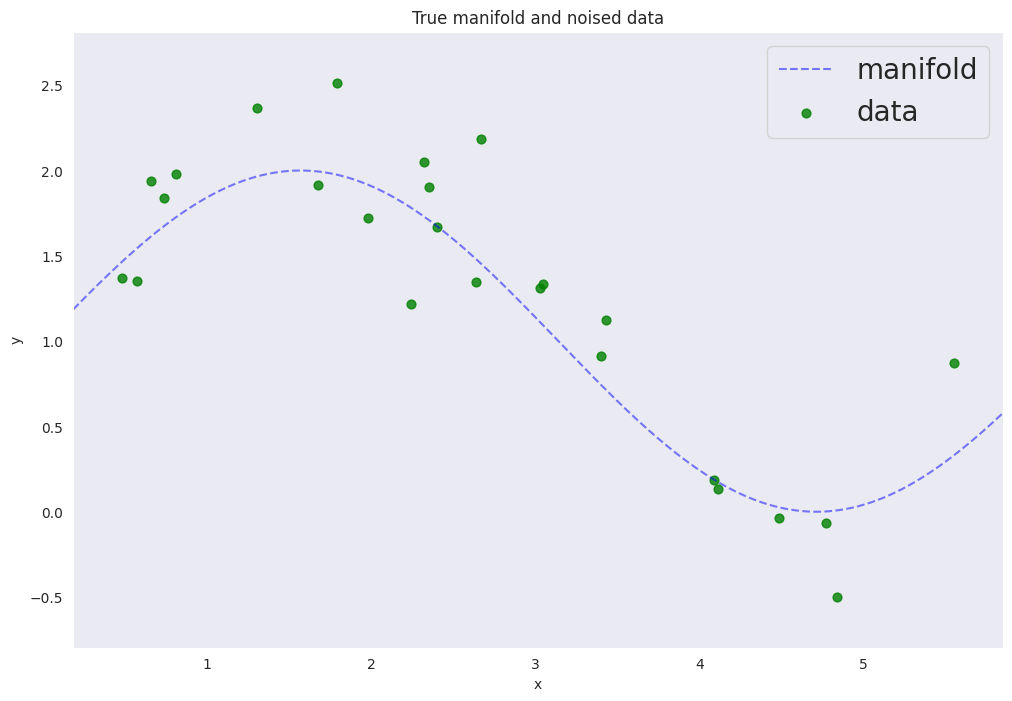

In [71]:
# sample 25 points from 1000 available from noised sin manifold 
data = generate_wave_set(1000, 25)

print('Shape of X is', data['x_train'].shape)
print('Head of X is', data['x_train'][:10])

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')
plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('True manifold and noised data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Top rows of X
[[1.         0.48428956]
 [1.         0.57234221]
 [1.         0.66039485]
 [1.         0.74215802]
 [1.         0.81134225]]
Fitted params
[ 2.42648096 -0.42818065]


/tmp/ipykernel_2965505/2859673993.py:13: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')


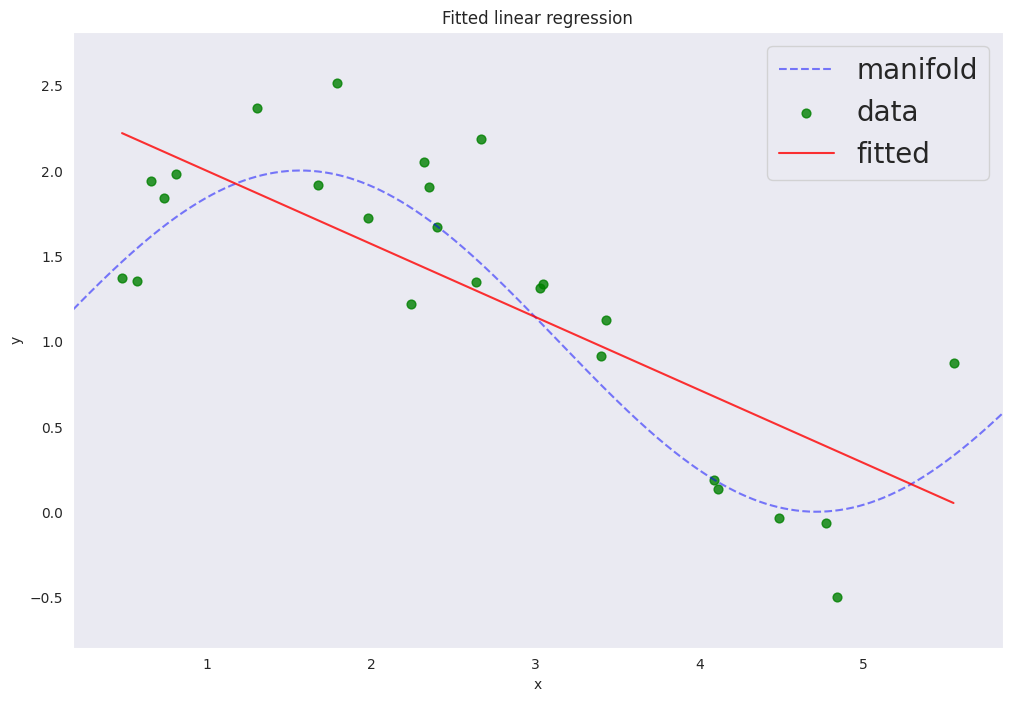

In [72]:
# add column of ones to the first position
X = np.array([np.ones(data['x_train'].shape[0]), data['x_train']]).T
print('Top rows of X')
print(X[:5, :])
# linear algebra magic of numpy
w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), data['y_train'])
print('Fitted params')
print(w)
y_hat = np.dot(w, X.T)

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')

plt.plot(data['x_train'], y_hat, 'r', alpha=0.8, label='fitted')

plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Fitted linear regression')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [73]:
np.mean((data['y_train'] - y_hat)**2)

np.float64(0.26704367617359787)

# Polynomial regression

Lets restrict set of hypothesis such that it would contain all polynomials of degree $\large p$. For number of features $\large m = 1$ hypothesis set is:
$$\large \begin{array}{rcl} \forall h \in \mathcal{H}, h\left(x\right) &=& w_0 + w_1 x + w_1 x^2 + \cdots + w_n x^p \\
&=& \sum_{i=0}^p w_i x^i
\end{array}$$

Nothing more changes, we just added exponentially more features then it was before.

/tmp/ipykernel_2965505/2314537286.py:10: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')


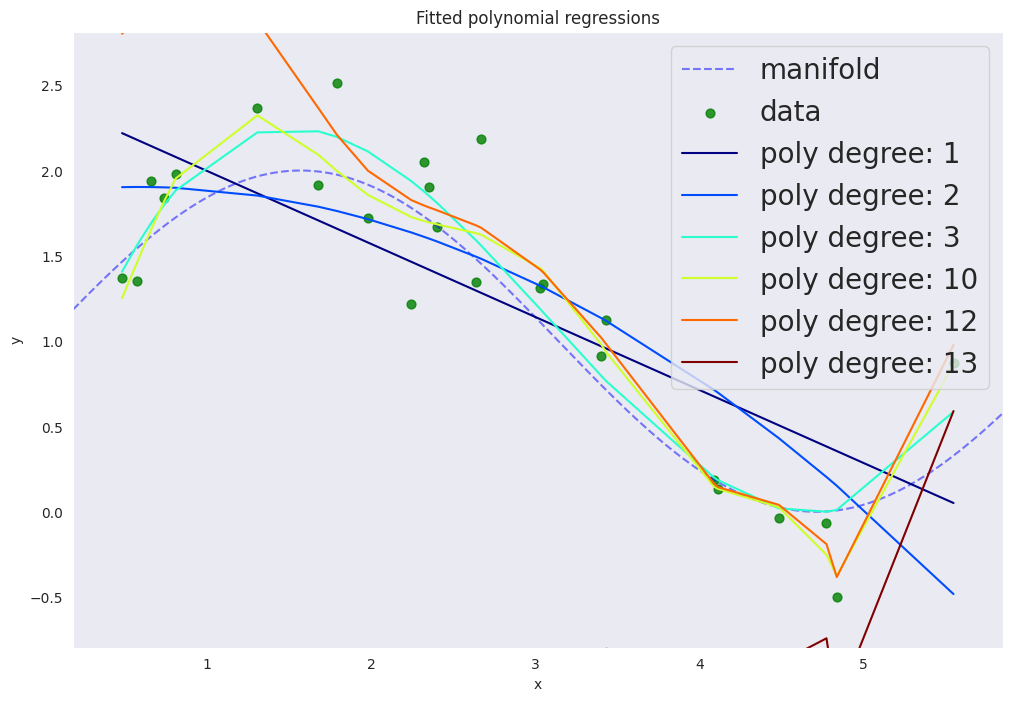

In [74]:
# define list with degrees of polynomials to investigate
degree_list = [1, 2, 3, 10, 12, 13]
# get color palette
cmap = plt.get_cmap('jet')
# compute individual color for each curve
colors = [cmap(i) for i in np.linspace(0, 1, len(degree_list))]

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')

# save weights of all fitted polynomial regressions
w_list = []
err = []
for ix, degree in enumerate(degree_list):
    # list with polynomial features for each degree
    dlist = [np.ones(data['x_train'].shape[0])] + \
            list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
    X = np.array(dlist).T
    w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), data['y_train'])
    w_list.append((degree, w))
    y_hat = np.dot(w, X.T)
    err.append(np.mean((data['y_train'] - y_hat)**2))
    plt.plot(data['x_train'], y_hat, color=colors[ix], label='poly degree: %i' % degree)

plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Fitted polynomial regressions')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

In [75]:
for p, e in zip(degree_list, err):
    print(p, e)

1 0.26704367617359787
2 0.22495097556913013
3 0.08217051592252778
10 0.05460721067447818
12 0.3676276130765861
13 7.932067707360582


/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


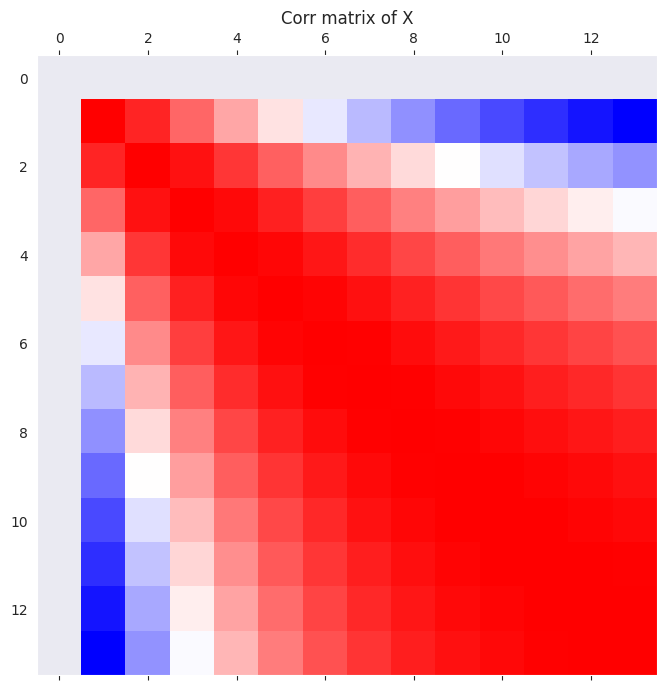

In [76]:
# Correlation matrix
plt.matshow(np.corrcoef(X.T), cmap=plt.cm.bwr)
plt.title('Corr matrix of X')
plt.show()

In [77]:
# eigenvalues for poly-12 features, we can see multicollinearity
np.linalg.eigvals(np.cov(X[:, 1:-1].T))

array([ 3.05178721e+16,  1.79504813e+12,  3.12307508e+08,  2.86789646e+05,
        8.47981271e+02,  8.30647426e+00,  1.55144159e-01,  6.76843735e-03,
        1.06684416e-03,  2.82670956e-04,  1.66056981e-05, -1.64648936e-08])

In [78]:
# eigenvalues for poly-13 features, we can see multicollinearity and complex eigenvalues
np.linalg.eigvals(np.cov(X[:, 1:].T))

array([ 9.29965299e+17+0.j        ,  4.04567033e+13+0.j        ,
        5.44657111e+09+0.j        ,  3.54104756e+06+0.j        ,
        8.36746290e+03+0.j        ,  6.82329500e+01+0.j        ,
        9.52774959e-01+0.j        , -2.76919209e-02+0.j        ,
        5.03738101e-03+0.00820059j,  5.03738101e-03-0.00820059j,
        1.67803430e-04+0.j        , -4.03866115e-06+0.j        ,
        2.23042869e-07+0.j        ])

In [79]:
w_list

[(1, array([ 2.42648096, -0.42818065])),
 (2, array([ 1.87006172,  0.11396008, -0.09699495])),
 (3, array([ 0.26172424,  2.96275937, -1.30210822,  0.1403494 ])),
 (10,
  array([ 7.30799050e-01, -8.60775870e-01,  5.03712362e+00, -2.06908865e-01,
         -6.10571230e+00,  5.16058717e+00, -1.80270767e+00,  2.68665908e-01,
         -2.00141067e-03, -3.71795874e-03,  2.88067744e-04])),
 (12,
  array([-6.21769227e+00,  6.11526326e+01, -1.73214719e+02,  2.67208254e+02,
         -2.42124946e+02,  1.30011668e+02, -3.78100238e+01,  2.56109333e+00,
          2.17964885e+00, -8.57055159e-01,  1.49026234e-01, -1.31942511e-02,
          4.82480296e-04])),
 (13,
  array([-2.66192951e+01,  1.39929195e+02, -3.13742284e+02,  3.30806006e+02,
         -1.18044511e+02, -8.84031664e+01,  1.22274808e+02, -6.24742042e+01,
          1.64505626e+01, -1.79729512e+00, -1.66542579e-01,  7.55542738e-02,
         -8.75701884e-03,  3.65044367e-04]))]

Есть только одно замечание — не надо пользоваться формулой `(X^T X^{-1}) X^T` для вычисления коэффициентов линейной регрессии. Проблема с расходящимися значениями хорошо известна и на практике используют `QR` или `SVD`.

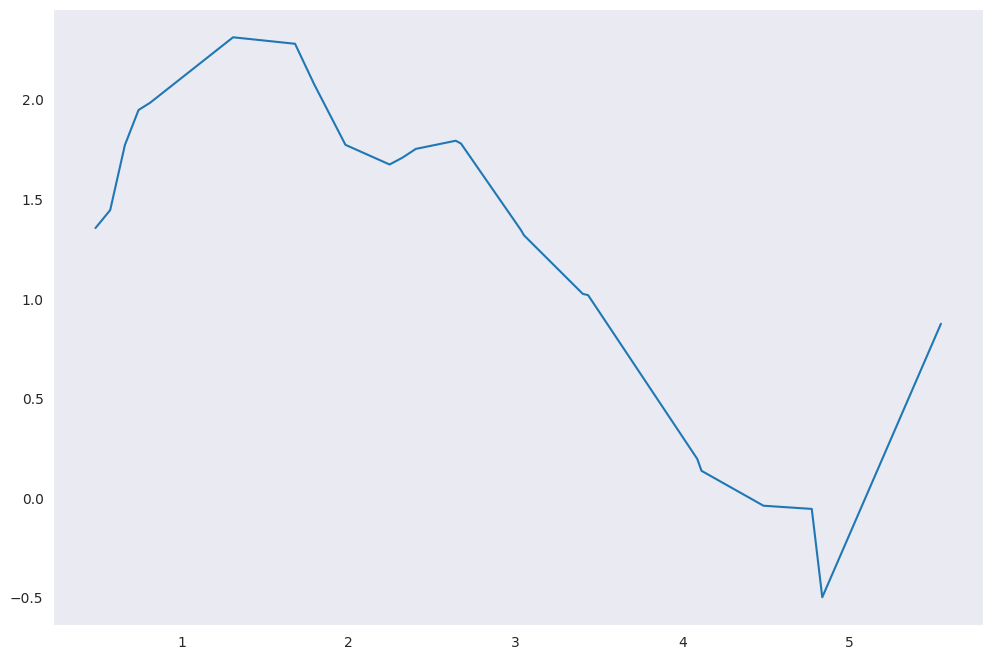

In [80]:
degree = 13
dlist = [np.ones(data['x_train'].shape[0])] + \
                list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
X = np.array(dlist).T

q, r = np.linalg.qr(X)

y_hat = np.dot(np.dot(q, q.T), data['y_train'])
plt.plot(data['x_train'], y_hat, label='poly degree: %i' % degree)

Lets look closer to magnitude of the fitted coefficients (weights).

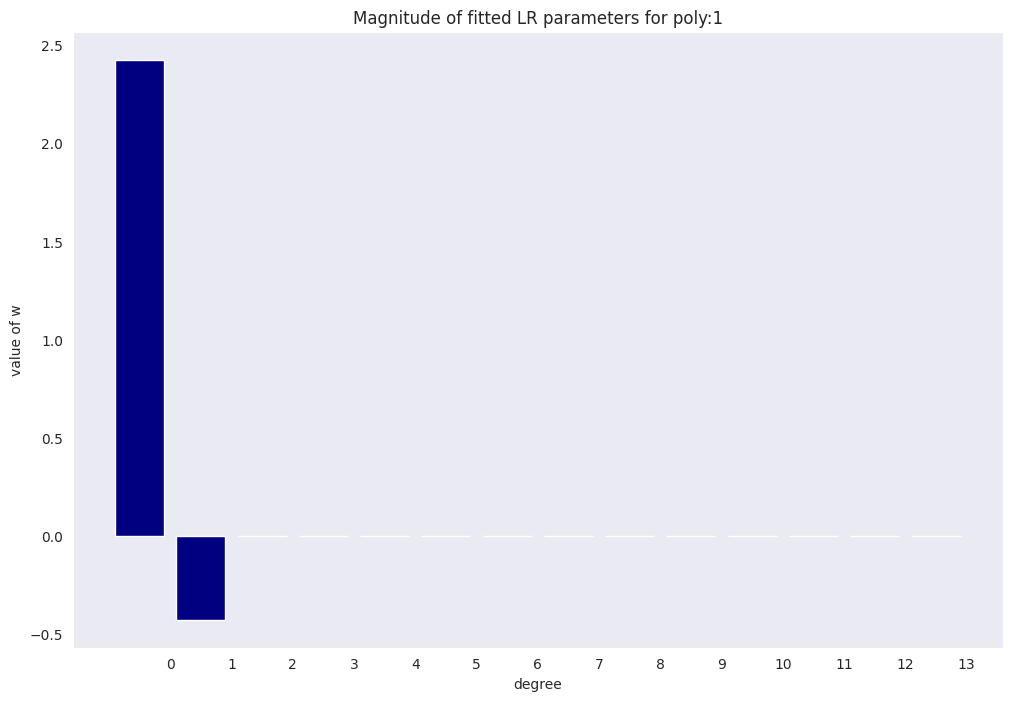

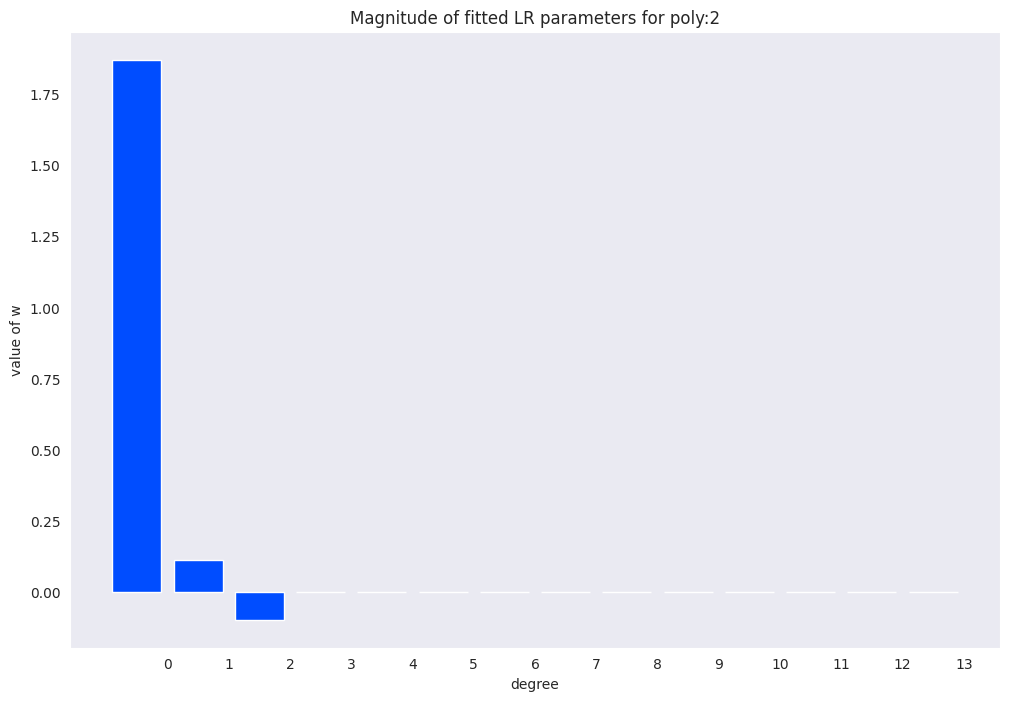

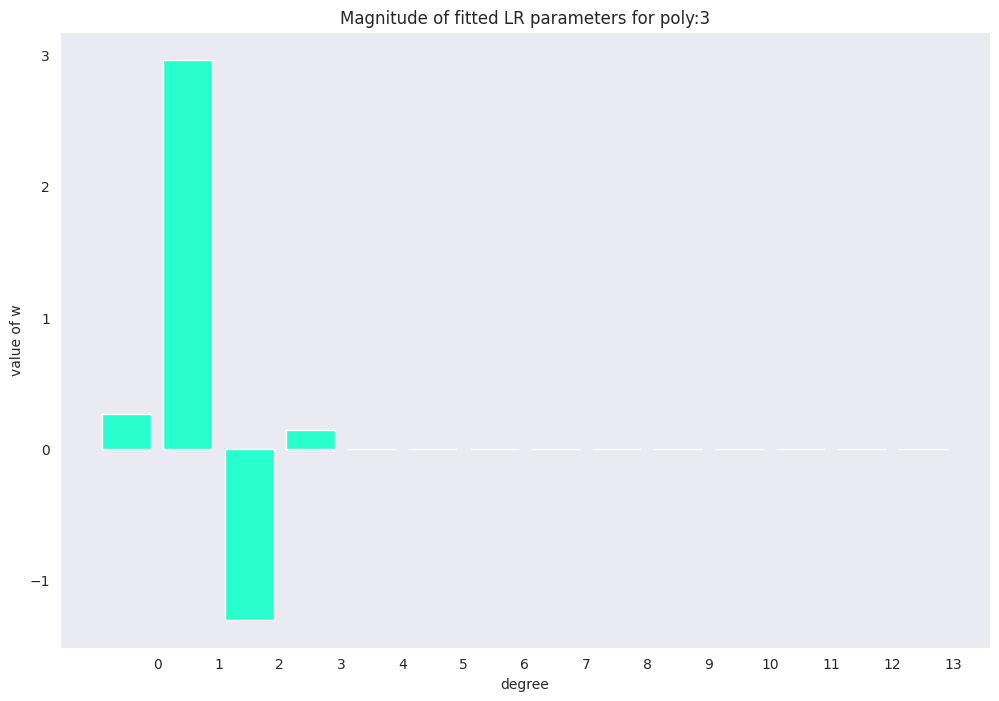

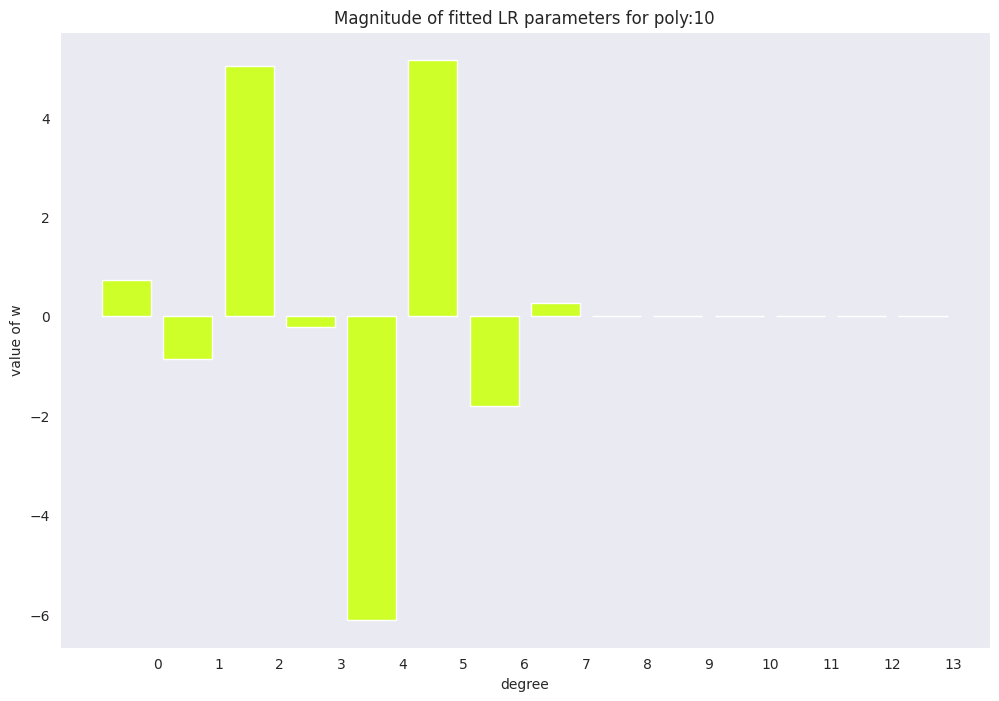

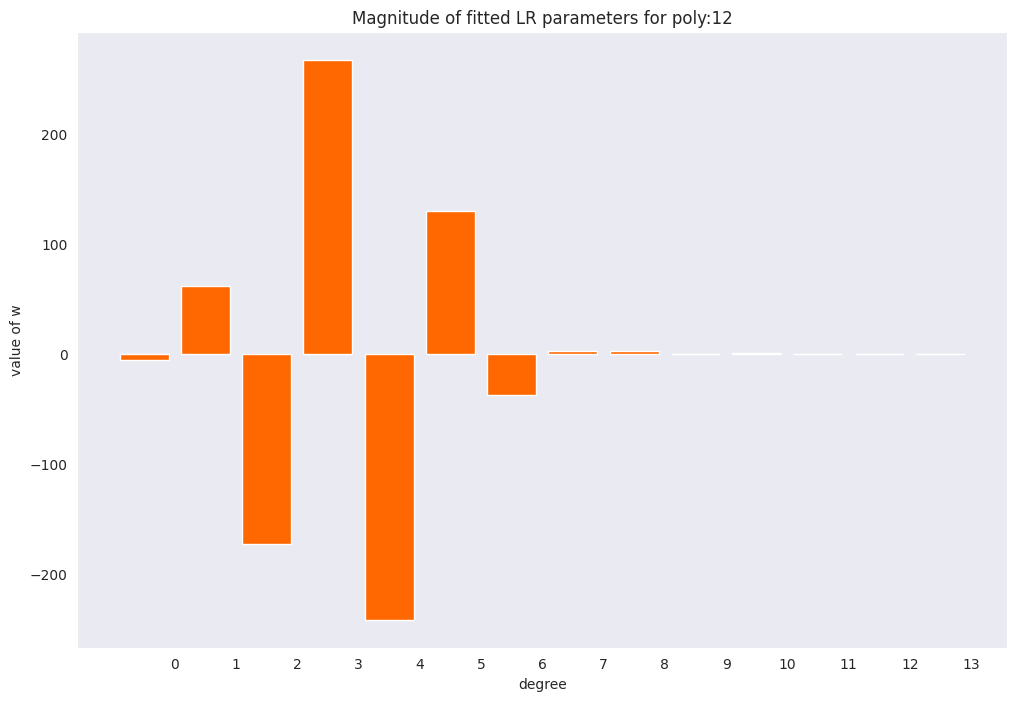

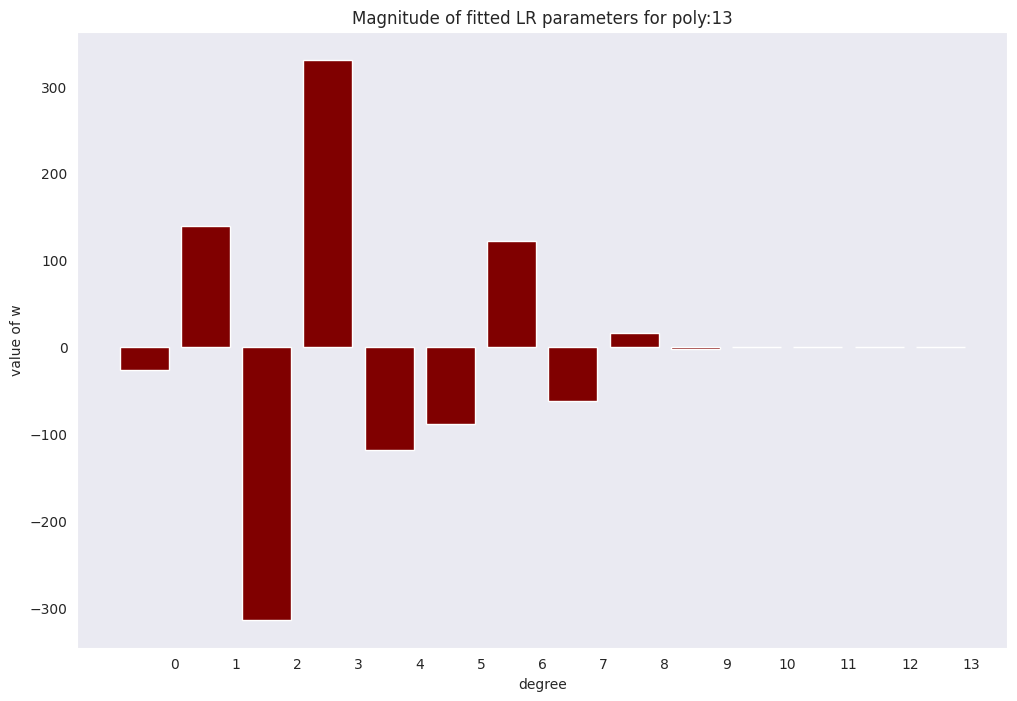

In [81]:
for ix, t in enumerate(w_list):
    degree, w = t
    fig, ax = plt.subplots()
    plt.bar(range(max(degree_list) + 1), np.hstack((w, [0]*(max(degree_list) - w.shape[0] + 1))), color=colors[ix])
    plt.title('Magnitude of fitted LR parameters for poly:%i' % degree)
    plt.xlabel('degree')
    plt.ylabel('value of w')
    ax.set_xticks(np.array(range(max(degree_list) + 1)) + 0.5)
    ax.set_xticklabels(range(max(degree_list) + 1))
    plt.show()

# Regularization

We can see one of the symptoms of overfitting: function try to interpolate data (pass throught each point). We can notice that magnitude of weights is increasing with the degree of polynomial. What about to add some penalty term for big weights? So general case of regularization with penalty term is:
$$\large \mathcal{L}_{reg} \left(X, \vec{y}, \vec{w}\right) = \mathcal{L}\left(X, \vec{y}, \vec{w}\right) + \lambda R\left(\vec{w}\right)$$
where:
* $\large \lambda$ is regularization parameter

# L2 regularization

Lets penalize for large L2 norm of the weights vector:
$$\large R\left(\vec{w}\right) = \frac{1}{2} \left\| \vec{w} \right\|_2^2 = \frac{1}{2} \sum_{j=1}^m w_j^2 = \frac{1}{2} \vec{w}^T \vec{w}$$
then new objective will be:
$$\large \mathcal{L}\left(X, \vec{y}, \vec{w} \right) = \frac{1}{2} \left(\vec{y} - X \vec{w}\right)^T \left(\vec{y} - X \vec{w}\right) + \frac{\lambda}{2} \vec{w}^T \vec{w}$$
Lets find derivative wrt to $\large \vec{w}$:
$$\large \begin{array}{rcl}\Large \frac{\partial \mathcal{L}}{\partial \vec{w}} &=& \frac{\partial}{\partial \vec{w}} \left(\frac{1}{2} \left(\vec{y} - X \vec{w}\right)^T \left(\vec{y} - X \vec{w}\right) + \frac{\lambda}{2} \vec{w}^T \vec{w}\right) \\
&=& \frac{\partial}{\partial \vec{w}}\left( \frac{1}{2} \left( \vec{y}^T \vec{y} -2\vec{y}^T X \vec{w} + \vec{w}^T X^T X \vec{w}\right) + \frac{\lambda}{2} \vec{w}^T \vec{w} \right) \\
&=& -X^T \vec{y} + X^T X \vec{w} + \lambda \vec{w}
\end{array}$$
And final solution:
$$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} = 0 &\Leftrightarrow& -X^T \vec{y} + X^T X \vec{w} + \lambda \vec{w} = 0 \\
&\Leftrightarrow& X^T X \vec{w} + \lambda \vec{w} = X^T \vec{y} \\
&\Leftrightarrow& \left(X^T X + \lambda E\right) \vec{w} = X^T \vec{y} \\
&\Leftrightarrow& \vec{w} = \left(X^T X + \lambda E\right)^{-1} X^T \vec{y}
\end{array}$$

/tmp/ipykernel_2965505/1425661588.py:10: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')


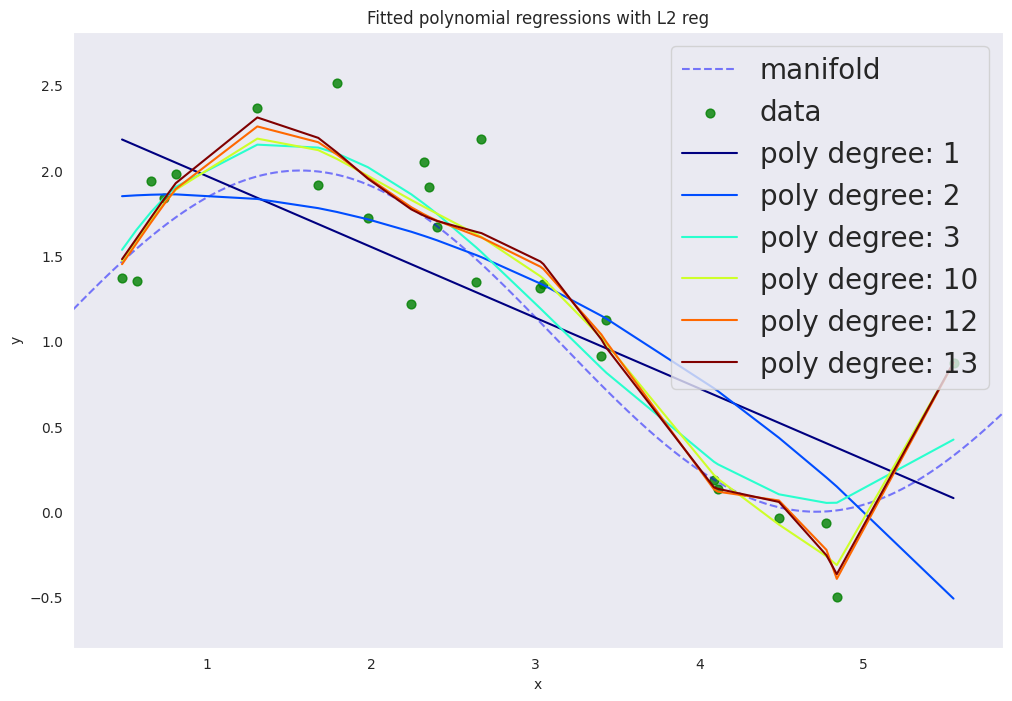

In [82]:
# define regularization parameter
lmbd = 0.1

degree_list = [1, 2, 3, 10, 12, 13]
cmap = plt.get_cmap('jet')
colors = [cmap(i) for i in np.linspace(0, 1, len(degree_list))]

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')

w_list_l2 = []
err = []
for ix, degree in enumerate(degree_list):
    dlist = [[1]*data['x_train'].shape[0]] + list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
    X = np.array(dlist).T
    w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X) + lmbd*np.eye(X.shape[1])), X.T), data['y_train'])
    w_list_l2.append((degree, w))
    y_hat = np.dot(w, X.T)
    plt.plot(data['x_train'], y_hat, color=colors[ix], label='poly degree: %i' % degree)
    err.append(np.mean((data['y_train'] - y_hat)**2))

plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Fitted polynomial regressions with L2 reg')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

In [83]:
for p, e in zip(degree_list, err):
    print(p, e)

1 0.2674811533072718
2 0.22546740447227415
3 0.08803220241719859
10 0.05833842193904601
12 0.0558724730454312
13 0.055921573536894406


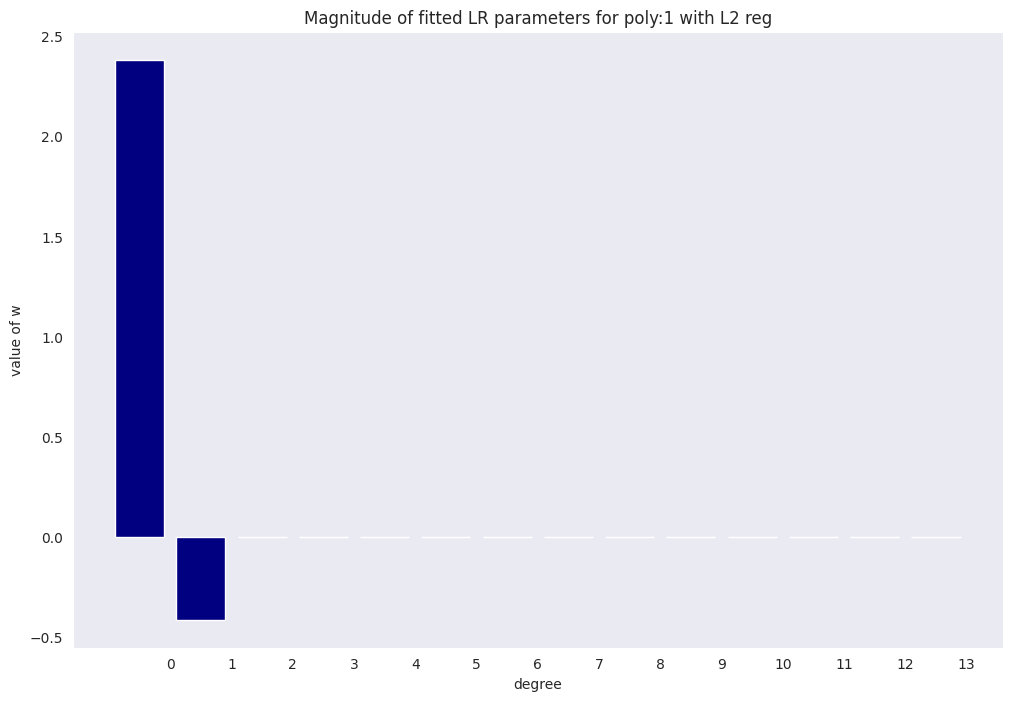

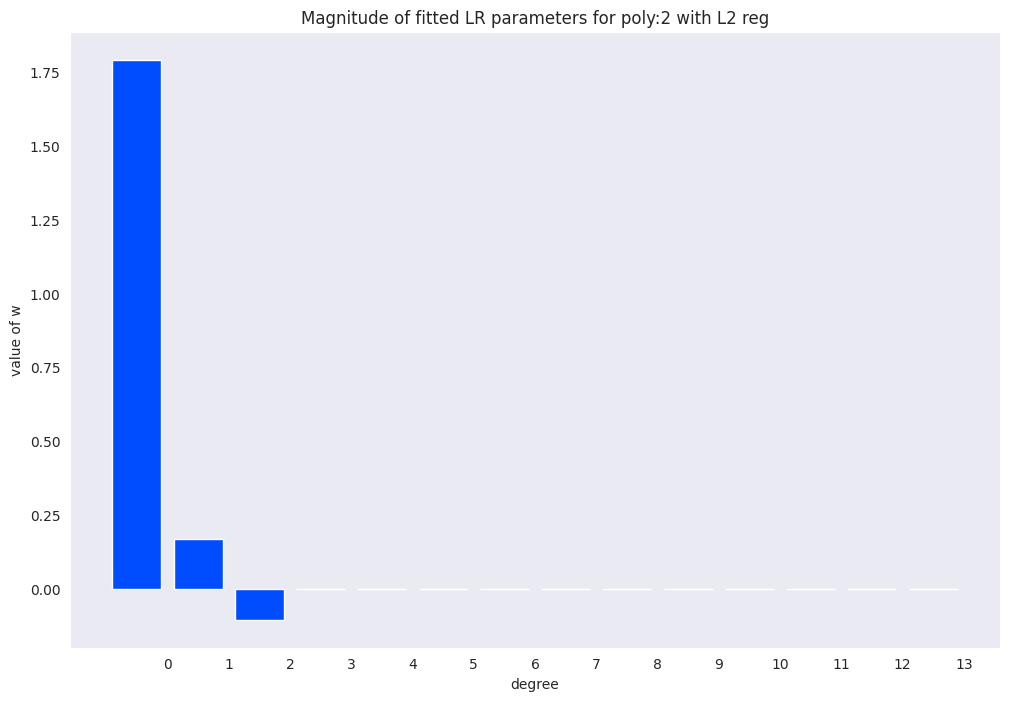

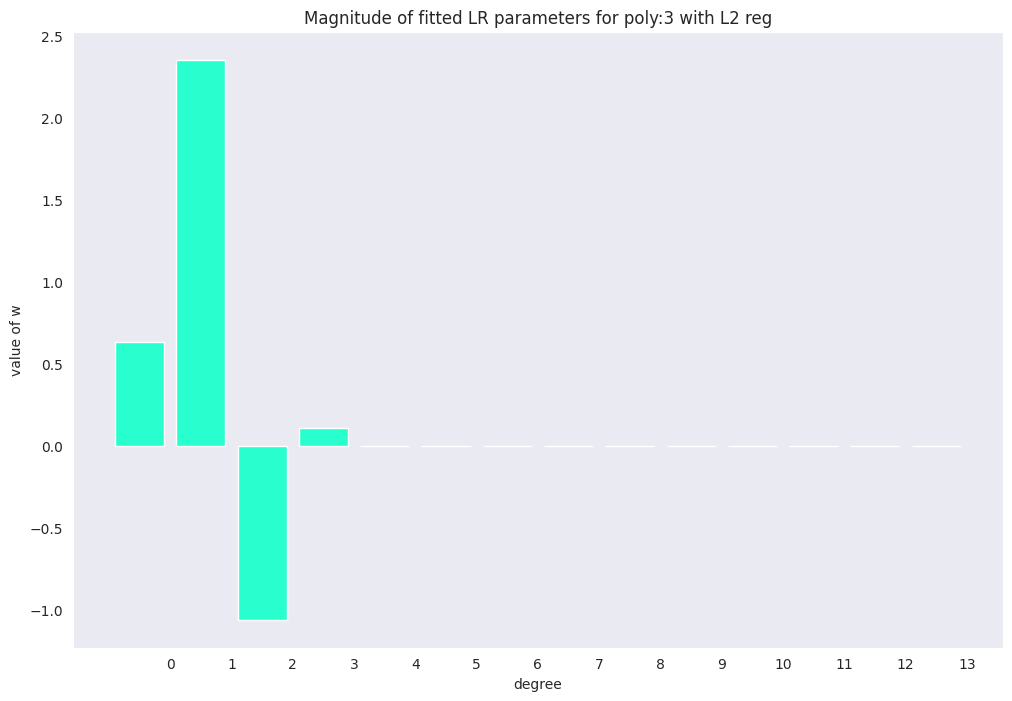

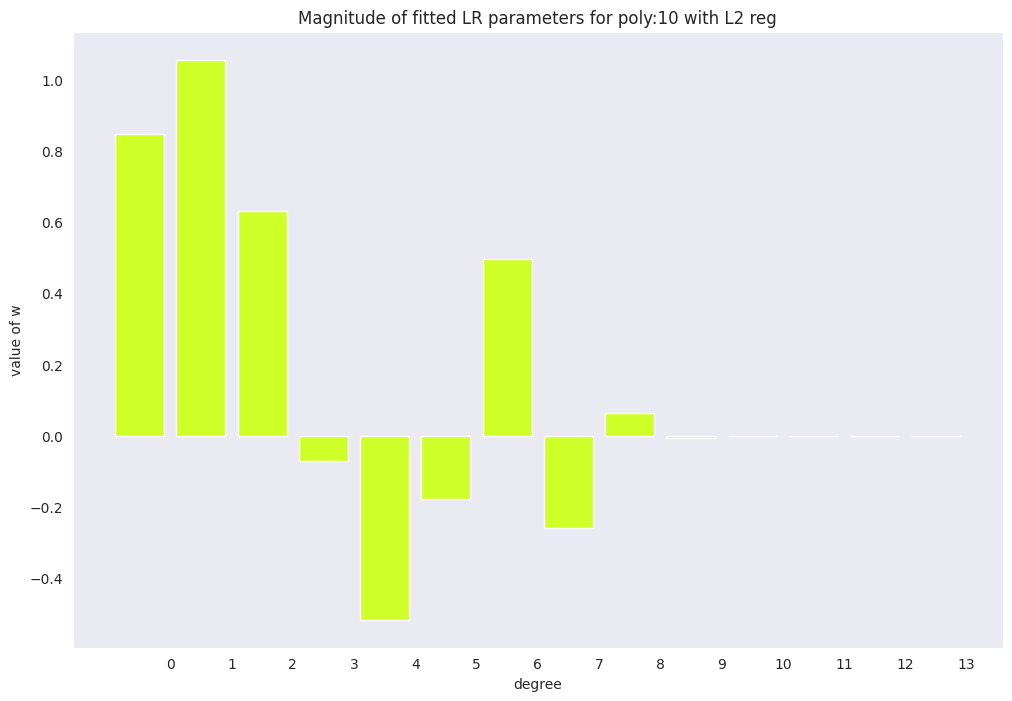

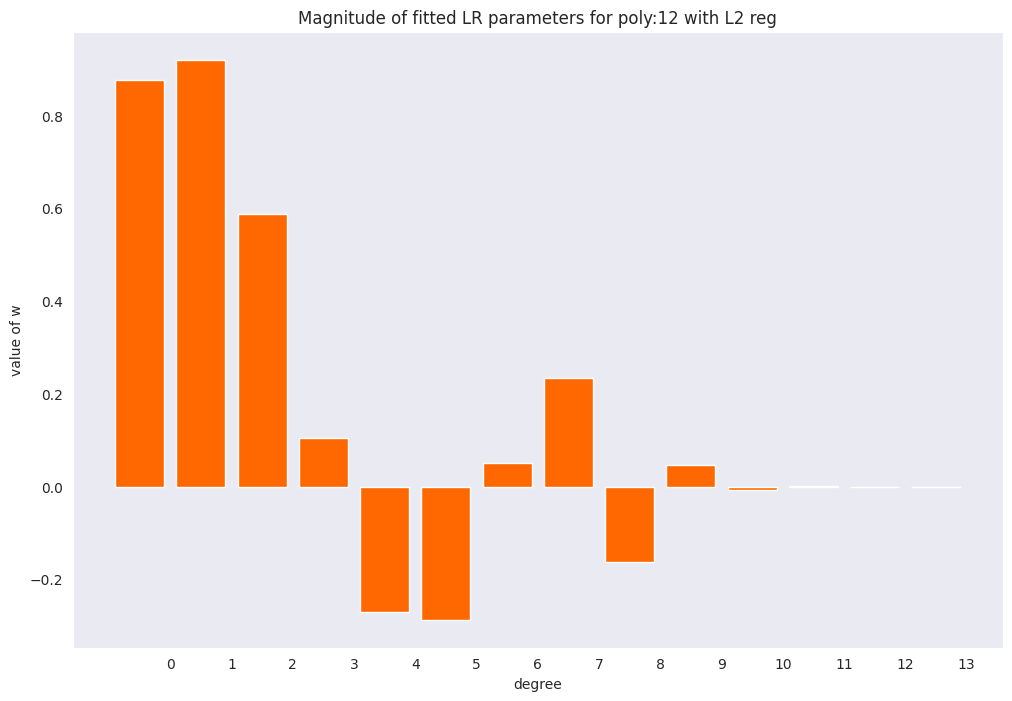

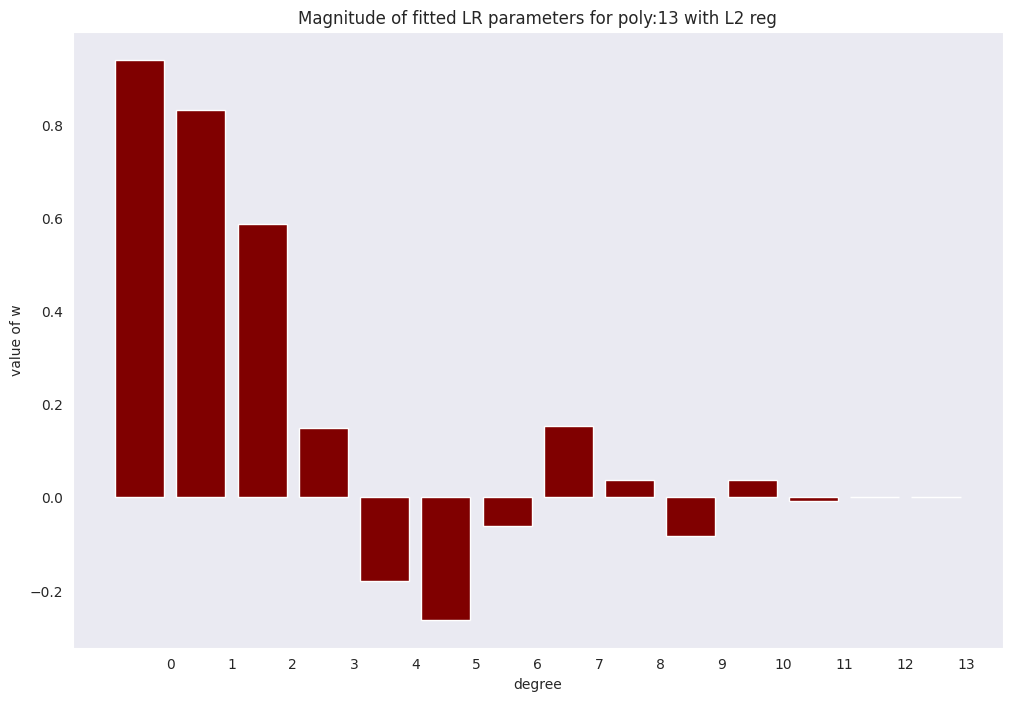

In [84]:
for ix, t in enumerate(w_list_l2):
    degree, w = t
    fig, ax = plt.subplots()
    plt.bar(range(max(degree_list) + 1), np.hstack((w, [0]*(max(degree_list) - w.shape[0] + 1))), color=colors[ix])
    plt.title('Magnitude of fitted LR parameters for poly:%i with L2 reg' % degree)
    plt.xlabel('degree')
    plt.ylabel('value of w')
    ax.set_xticks(np.array(range(max(degree_list) + 1)) + 0.5)
    ax.set_xticklabels(range(max(degree_list) + 1))
    plt.show()

# L1 regularization
<center>or LASSO (least absolute shrinkage and selection operator)</center>

Lets penalty for large L1 norm of the weights vector:
$$\large R\left(\vec{w}\right) = \left\| \vec{w} \right\|_1 = \sum_{j=1}^m \left| w_j \right|$$
then new objective will be:
$$\large \mathcal{L}\left(X, \vec{y}, \vec{w} \right) = \frac{1}{2n} \sum_{i=1}^n \left(\vec{x_i}^T \vec{w} - y_i\right)^2 + \lambda \sum_{j=1}^m \left| w_j \right|$$
Unfortunately, in general, there is no explicit formula for optimal weights. We will use gradient descent to estimate optimal values of weights. Lets find gradient wrt weights:
$$\large \frac{\partial \mathcal{L}}{\partial w_j} = \frac{1}{n}\sum_{i=1}^n \left(\vec{x_i}^T \vec{w} - y_i\right) \vec{x_i} + \lambda \text{sign}(\vec{w})$$
So update formula of weights is:
$$\large \vec{w}_{\text{new}} := \vec{w} - \alpha \frac{\partial \mathcal{L}}{\partial \vec{w}}$$
where:
* $\large \alpha$ is step of gradient descent (learning rate)

In [85]:
lmbd = 1
degree = 13
dlist = [[1]*data['x_train'].shape[0]] + list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
X = np.array(dlist).T

# define MSE function to evaluate model
# we expect that durint training process this value will be decreasing
def mse(u, v):
    return ((u - v)**2).sum()/u.shape[0]

# initial weights of the model
w = np.array([-1.0] * X.shape[1])
# maximim number of iterations
n_iter = 20
# alpha or learning rate
lr = 0.00000001
# we will keep all MSE values to plot graph
loss = []
for ix in range(n_iter):
    w -= lr*(np.dot(np.dot(X, w) - data['y_train'], X)/X.shape[0] + lmbd*np.sign(w))
    y_hat = np.dot(X, w)
    loss.append(mse(data['y_train'], y_hat))
    print(loss[-1])

1.305123095804747e+38
1.2197910239760616e+58
1.1400381672468151e+78
1.0654997431797661e+98
9.958348196866645e+117
9.307247556352147e+137
8.698717434130208e+157
8.129974467821911e+177
7.598417277942674e+197
7.101614569425054e+217
6.637294011092436e+237
6.203331842219378e+257
5.797743158639918e+277
5.418672833973348e+297
inf
inf
inf
inf
inf
inf


/tmp/ipykernel_2965505/1791156529.py:9: RuntimeWarning: overflow encountered in square
  return ((u - v)**2).sum()/u.shape[0]


# Standardization 

To avoid divergence and make magnitude of gradients to be at the same scale we can remove the mean from each feature and scale them to unit variance. First we need to compute sample mean and sample standard deviation of the training set:
$$\large \begin{array}{rcl} \overline{\mu}_{\cdot j} &=& \frac{1}{n} \sum_{i=1}^n x_{ij} \\
\overline{\sigma}_{\cdot j} &=& \sqrt{\frac{1}{n} \sum_{i=1}^n \left( x_{ij} - \overline{\mu}_{\cdot j} \right)}
\end{array}$$
Then apply transformation:
$$\large \vec{x}_{\text{new}} = \frac{\vec{x} - \overline{\mu}}{\overline{\sigma}}$$

In [86]:
# import norm class from scipy
from scipy.stats import norm

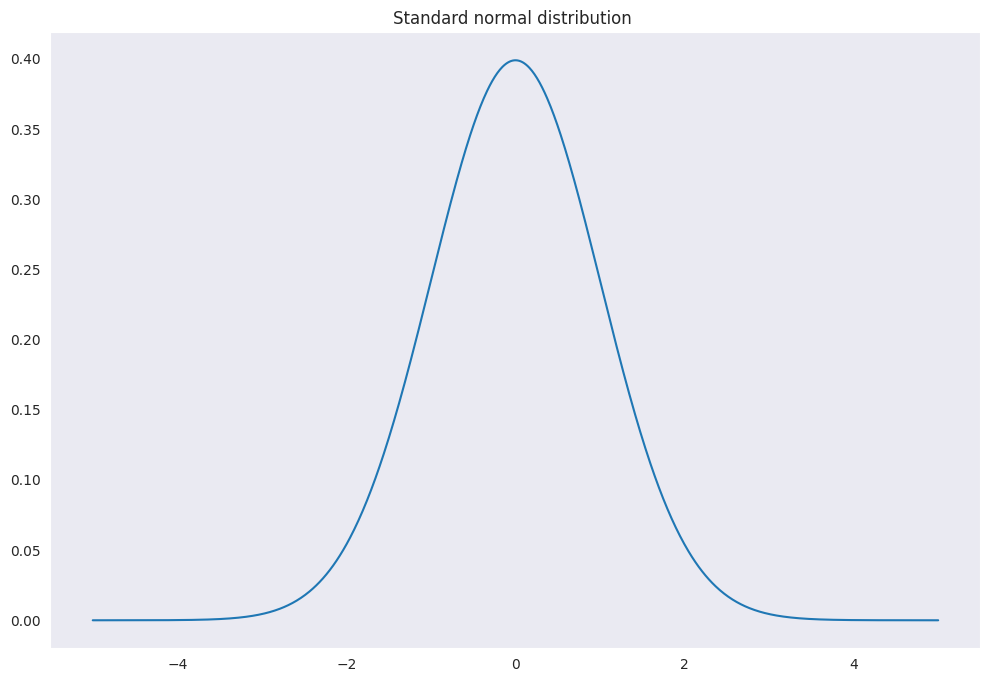

In [87]:
plt.plot(np.linspace(-5, 5, 1000), norm.pdf(np.linspace(-5, 5, 1000)))
plt.title('Standard normal distribution ')
plt.show()

X mean:
[1.00000000e+00 2.61717625e+00 8.89178866e+00 3.46858633e+01
 1.47337824e+02 6.62964718e+02 3.10664370e+03 1.49946179e+04
 7.40097896e+04 3.71757450e+05 1.89408958e+06 9.76488362e+06
 5.08473839e+07 2.67042329e+08]
X std
[0.00000000e+00 1.42904764e+00 8.26280332e+00 4.36295151e+01
 2.28694895e+02 1.20605446e+03 6.41842261e+03 3.44672461e+04
 1.86543640e+05 1.01602565e+06 5.56120143e+06 3.05530627e+07
 1.68325268e+08 9.29250585e+08]


/tmp/ipykernel_2965505/664178256.py:14: RuntimeWarning: invalid value encountered in divide
  X = (X - x_mean)/x_std


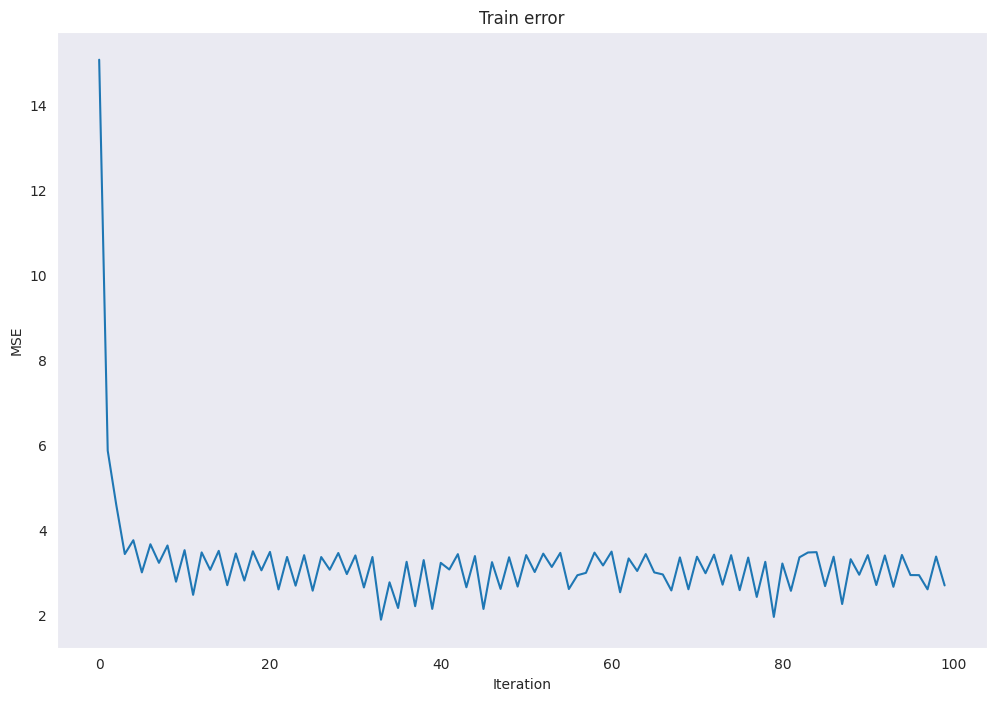

In [88]:
lmbd = 1
degree = 13
dlist = [[1]*data['x_train'].shape[0]] + list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
X = np.array(dlist).T
# compute sample mean
x_mean = X.mean(axis=0)
print('X mean:')
print(x_mean)
# compute sample std
x_std = X.std(axis=0)
print('X std')
print(x_std)
# apply transformation
X = (X - x_mean)/x_std
# fix first column with ones
X[:, 0] = 1.0

def mse(u, v):
    return ((u - v)**2).sum()/u.shape[0]

w = np.array([-1.0] * X.shape[1])
n_iter = 100
lr = 0.1
loss = []
for ix in range(n_iter):
    w -= lr*(np.dot(np.dot(X, w) - data['y_train'], X)/X.shape[0] + lmbd*np.sign(w))
    y_hat = np.dot(X, w)
    loss.append(mse(data['y_train'], y_hat))

plt.plot(loss)
plt.title('Train error')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.show()

Fitted params
[ 0.3058499  -0.10080591 -0.07401893 -0.08790983 -0.19003786 -0.08742071
 -0.22216986 -0.20988452 -0.0539194  -0.15158997 -0.0974371  -0.08506695
 -0.10815234 -0.16092109]


/tmp/ipykernel_2965505/2207865793.py:7: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')


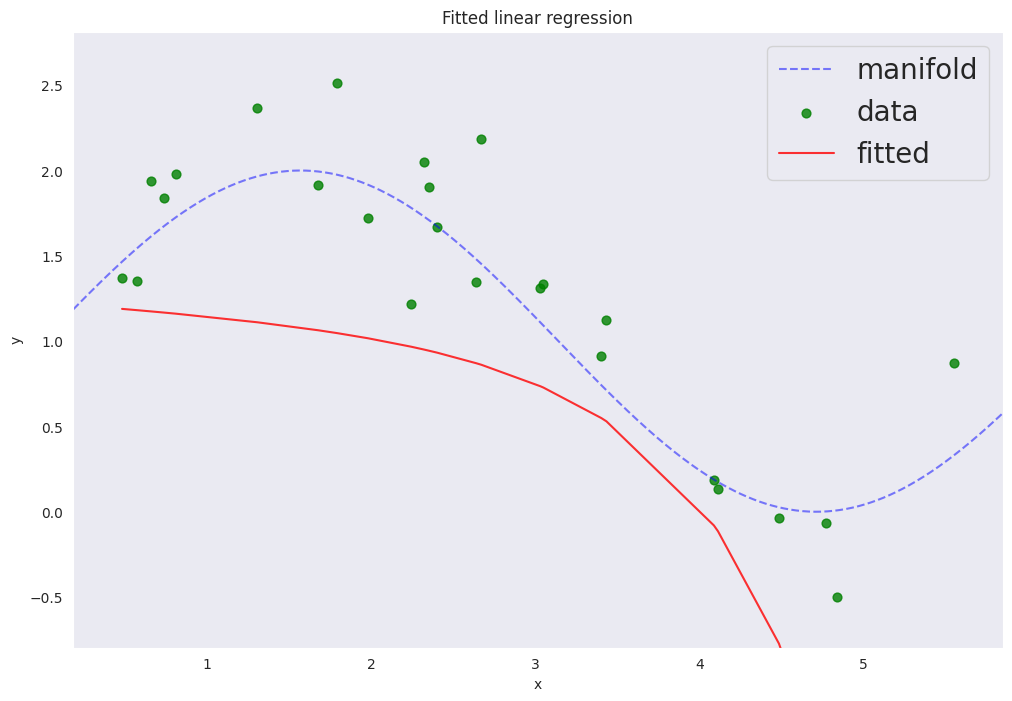

In [89]:
print('Fitted params')
print(w)
y_hat = np.dot(w, X.T)

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')

plt.plot(data['x_train'], y_hat, 'r', alpha=0.8, label='fitted')

plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Fitted linear regression')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Слишком сильная регуляризация! Смотри как поменяем ее дальше.

Lets prettify code and plot L1 regularized polynomial regressions

degree: 1 - error: 0.27204827362959105
Fitted params: [ 1.25579917 -0.56190218]
degree: 2 - error: 0.2379462439385814
Fitted params: [ 1.25579917 -0.15704908 -0.43069958]
degree: 3 - error: 0.2411803554956721
Fitted params: [ 1.25579917 -0.14742684 -0.29065819 -0.15296151]
degree: 10 - error: 0.18083419800331269
Fitted params: [ 1.25579917e+00 -1.19845413e-01 -3.28265410e-01 -2.54834087e-01
 -5.17750384e-02  7.29129111e-04 -2.61351330e-05 -2.64044217e-03
  6.34492592e-03  4.64321779e-02  1.79957445e-01]
degree: 12 - error: 0.16069034344410338
Fitted params: [ 1.25579917e+00 -9.19242627e-02 -3.15578676e-01 -2.76296840e-01
 -1.00211972e-01 -4.27708134e-03  4.34826680e-04  6.06088491e-03
  6.25516445e-03  1.04007944e-02  1.05556022e-02  9.98064658e-02
  1.81414397e-01]
degree: 13 - error: 0.15425054532757454
Fitted params: [ 1.25579917e+00 -8.05884185e-02 -3.20150208e-01 -2.80475539e-01
 -1.15244817e-01 -9.00978750e-05 -5.40278838e-03  1.27463056e-03
  3.69487061e-03  1.20821625e-03  5.77

/tmp/ipykernel_2965505/68171785.py:7: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')
/tmp/ipykernel_2965505/68171785.py:28: RuntimeWarning: invalid value encountered in divide
  X = (X - x_mean)/x_std


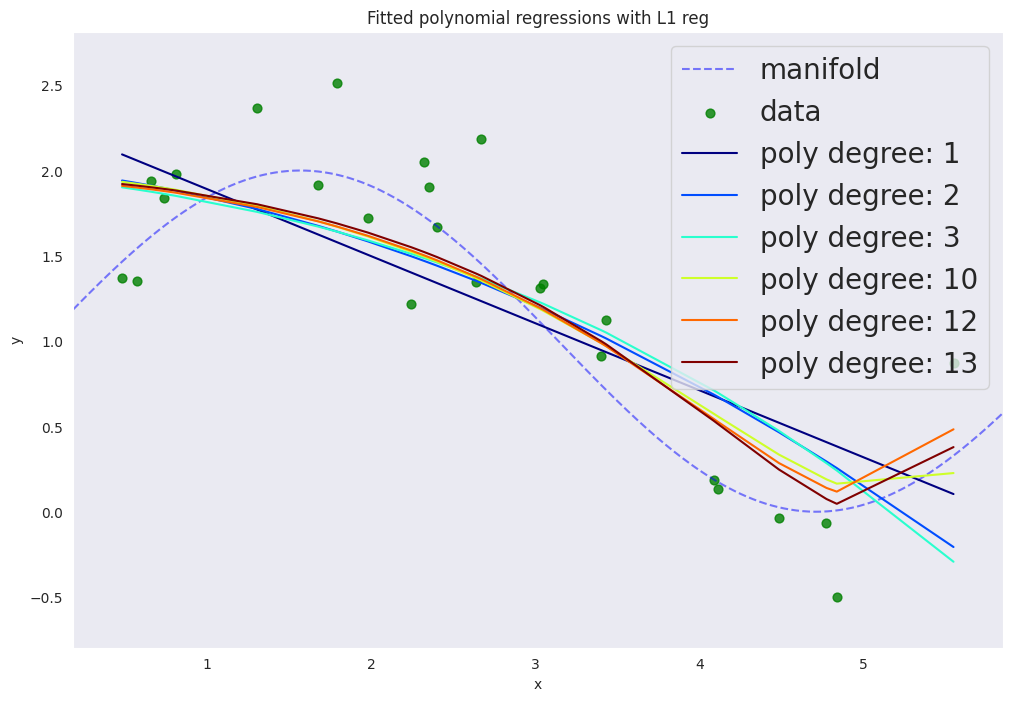

In [90]:

degree_list = [1, 2, 3, 10, 12, 13]
cmap = plt.get_cmap('jet')
colors = [cmap(i) for i in np.linspace(0, 1, len(degree_list))]

margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')

def mse(u, v):
    return ((u - v)**2).sum()/u.shape[0]

def fit_lr_l1(X, y, lmbd, n_iter=100, lr=0.1):
    w = np.array([-1.0] * X.shape[1])
    loss = []
    for ix_iter in range(n_iter):
        w -= lr*(np.dot(np.dot(X, w) - y, X)/X.shape[0] +lmbd*np.sign(w))
        y_hat = np.dot(X, w)
        loss.append(mse(y, y_hat))
    return w, y_hat, loss
    
w_list_l1 = []
err = []
for ix, degree in enumerate(degree_list):
    dlist = [[1]*data['x_train'].shape[0]] + list(map(lambda n: data['x_train']**n, range(1, degree + 1)))
    X = np.array(dlist).T
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)
    X = (X - x_mean)/x_std
    X[:, 0] = 1.0
    w, y_hat, loss = fit_lr_l1(X, data['y_train'], lmbd=0.05)
    w_list_l1.append((degree, w))
    plt.plot(data['x_train'], y_hat, color=colors[ix], label='poly degree: %i' % degree)
    err.append(np.mean((data['y_train'] - y_hat)**2))
    print('=======================')
    print(f"degree: {degree} - error: {err[-1]}")
    print(f'Fitted params: {w}')    
    

plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Fitted polynomial regressions with L1 reg')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

In [91]:
for p, e in zip(degree_list, err):
    print(p, e)

1 0.27204827362959105
2 0.2379462439385814
3 0.2411803554956721
10 0.18083419800331269
12 0.16069034344410338
13 0.15425054532757454


1 [ 1.25579917 -0.56190218]


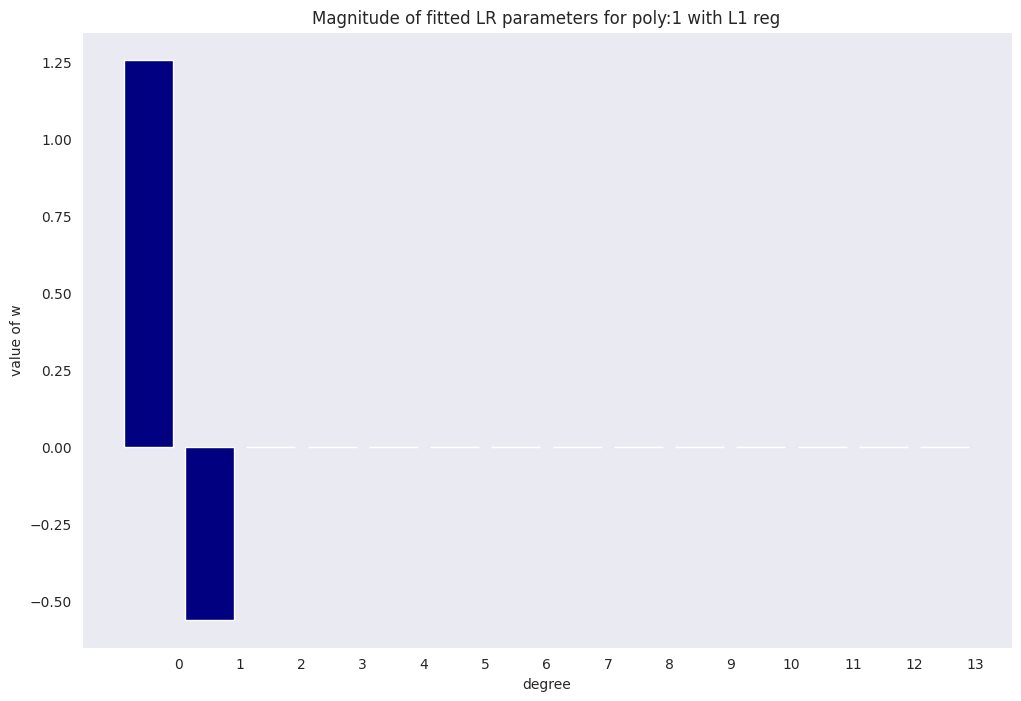

2 [ 1.25579917 -0.15704908 -0.43069958]


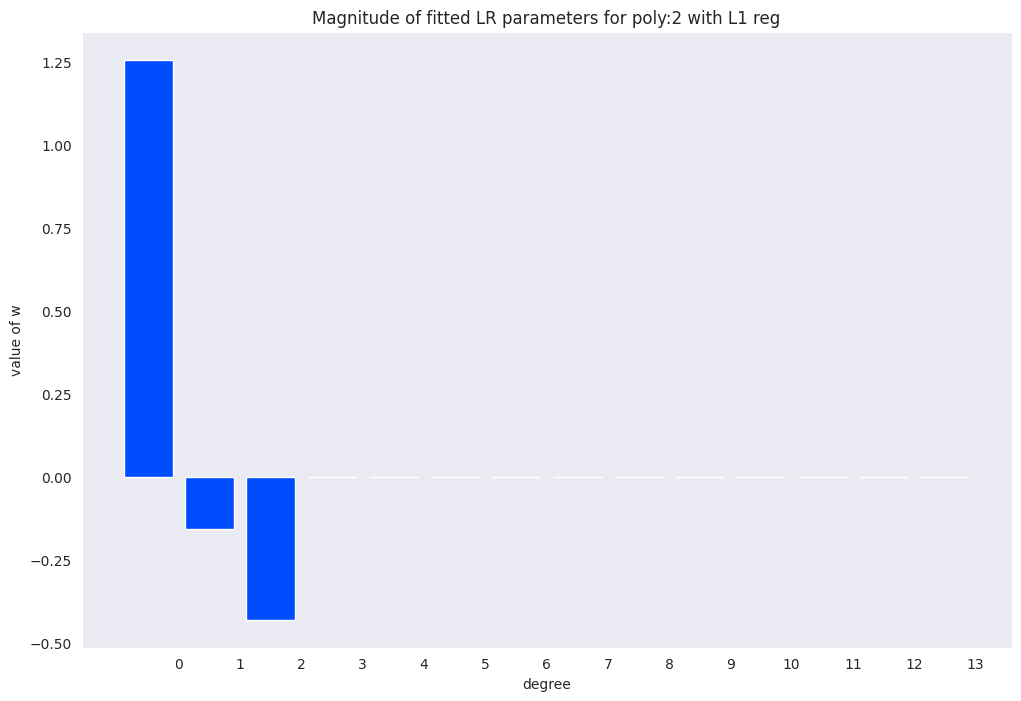

3 [ 1.25579917 -0.14742684 -0.29065819 -0.15296151]


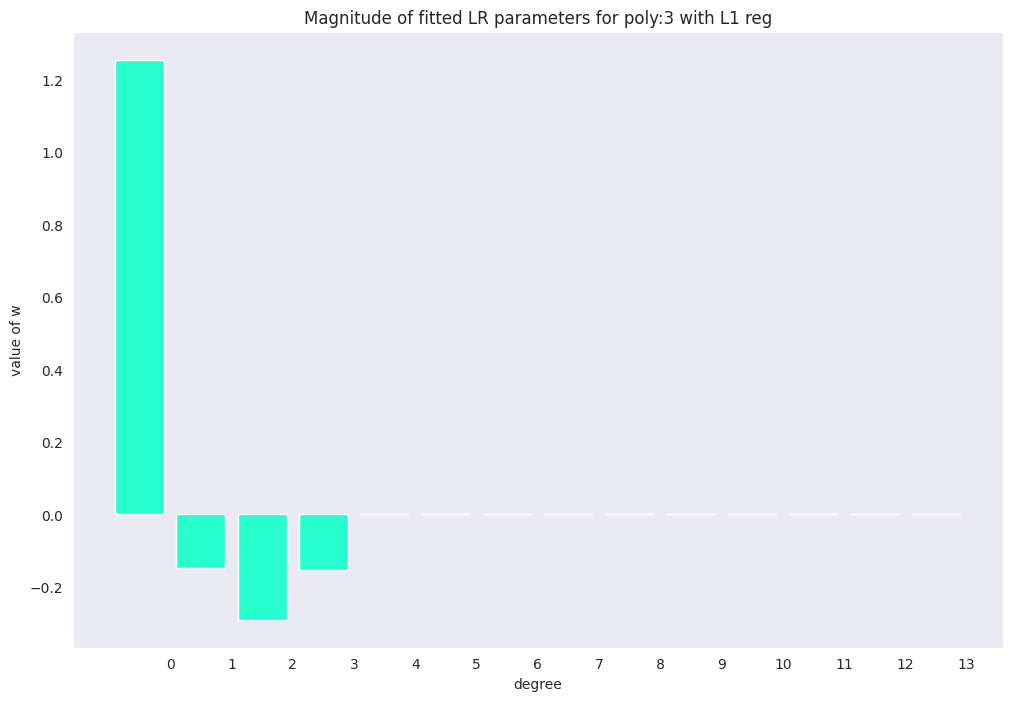

10 [ 1.25579917e+00 -1.19845413e-01 -3.28265410e-01 -2.54834087e-01
 -5.17750384e-02  7.29129111e-04 -2.61351330e-05 -2.64044217e-03
  6.34492592e-03  4.64321779e-02  1.79957445e-01]


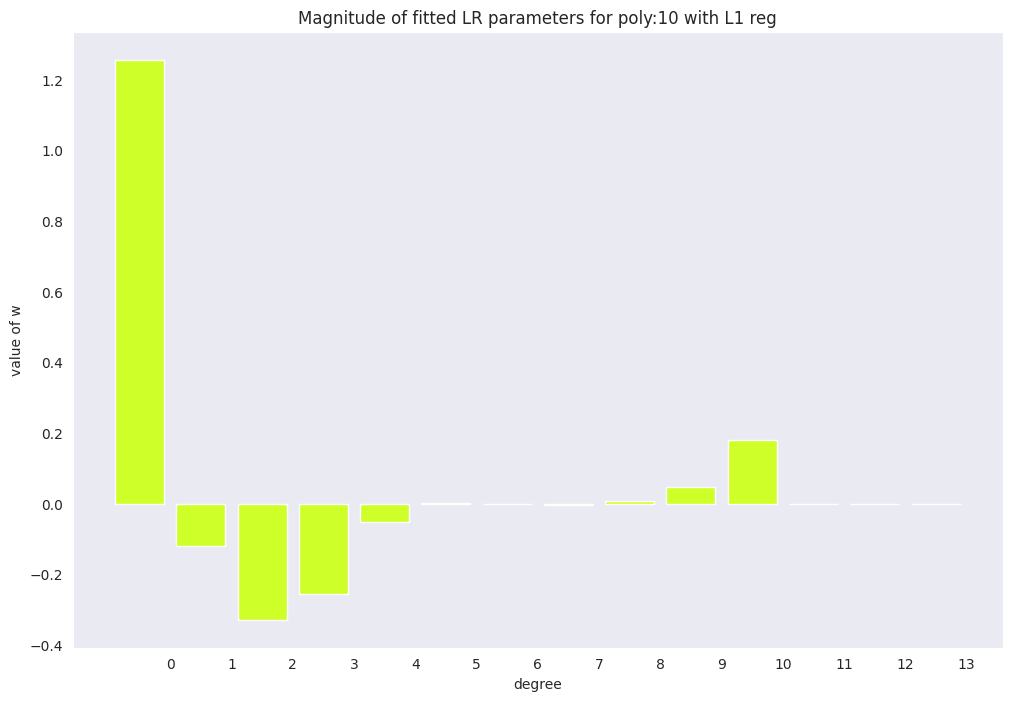

12 [ 1.25579917e+00 -9.19242627e-02 -3.15578676e-01 -2.76296840e-01
 -1.00211972e-01 -4.27708134e-03  4.34826680e-04  6.06088491e-03
  6.25516445e-03  1.04007944e-02  1.05556022e-02  9.98064658e-02
  1.81414397e-01]


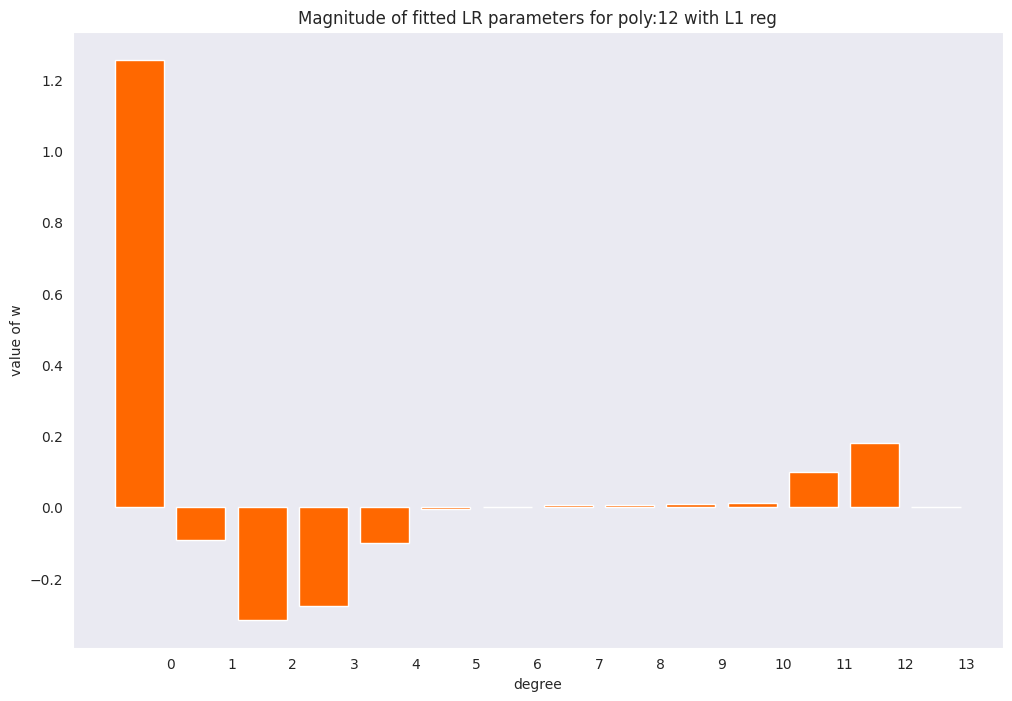

13 [ 1.25579917e+00 -8.05884185e-02 -3.20150208e-01 -2.80475539e-01
 -1.15244817e-01 -9.00978750e-05 -5.40278838e-03  1.27463056e-03
  3.69487061e-03  1.20821625e-03  5.77082935e-03  2.03400919e-02
  9.80439688e-02  1.71788321e-01]


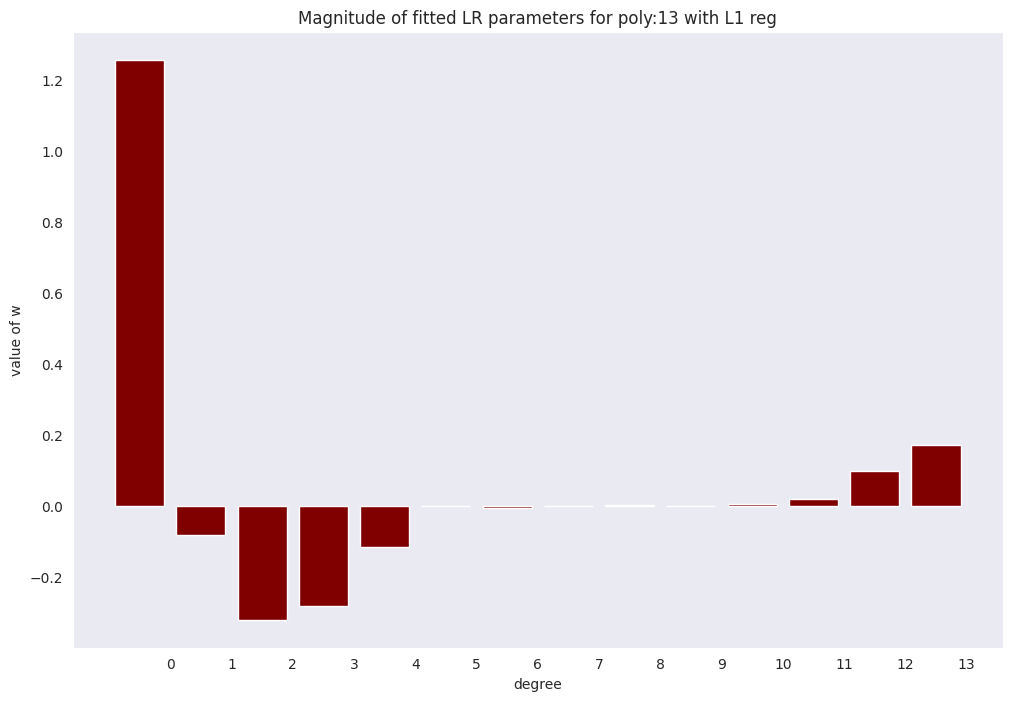

In [352]:
for ix, t in enumerate(w_list_l1):
    degree, w = t
    print(degree, w)
    fig, ax = plt.subplots()
    plt.bar(range(max(degree_list) + 1), np.hstack((w, [0]*(max(degree_list) - w.shape[0] + 1))), color=colors[ix])
    plt.title('Magnitude of fitted LR parameters for poly:%i with L1 reg' % degree)
    plt.xlabel('degree')
    plt.ylabel('value of w')
    ax.set_xticks(np.array(range(max(degree_list) + 1)) + 0.5)
    ax.set_xticklabels(range(max(degree_list) + 1))
    plt.show()

![5fcv](images/sklearn-logo.png)

# Model selection

Eventually our regularized linear regression model have not only weights $\large \vec{w}$ as parameters, at least one more - regularization hyperparameter $\large \lambda$:
$$\large \Theta = \left\{\vec{w}, \lambda\right\}$$

Moreover, we can't simultaneously tune weigts and regularization parameter. So we usually split dataset into at least three subsets (or variations):
* training set - for fitting parameters of the model
* validation set - for turning hyperparameters
* test set (hold out) - for final testing of the model, this set can not effect on any of parameters to keep test loss estimation honest.

Lets take one real dataset with boston house-prices from http://scikit-learn.org/stable/datasets/

In [155]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

raw_df = pd.read_csv('/opt/d.sidorko/ocr_research/study/mlcourse.ai/data/Boston.csv', sep=",", index_col=0)
print('Shape of the data:', raw_df.shape)

boston_data = np.array(raw_df.drop(['medv'], axis=1))
boston_target = np.array(raw_df['medv'])
boston_columns = raw_df.drop(['medv'], axis=1).columns

data = {}
# split in into train/test data
data['x_train'] = boston_data[100:, :]
data['x_test'] = boston_data[:100, :]
data['y_train'] = boston_target[100:]
data['y_test'] = boston_target[:100]

Shape of the data: (506, 14)


In [157]:
# lets look at head of the dataset
import pandas as pd
pd.DataFrame(boston_data, columns=boston_columns).head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


For further experiments we will use ElasticNet model from http://scikit-learn.org/stable/modules/linear_model.html, which use сonvex combination of L1 and L2 regularization.

ElasticNet:
$$\large \mathcal{L}\left(\Theta, X, \vec{y}\right) = \frac{1}{2n} \left\|X\vec{w} - \vec{y}\right\|_2^2 + \lambda \left( \gamma \left\|\vec{w}\right\|_1 + \frac{1}{2} \left(1 - \gamma\right) \left\|\vec{w}\right\|_2^2 \right)$$
where:
* $\lambda$ is for *alpha*
* $\gamma$ is gor *l1_ratio*

In [158]:
# import ElasticNet from sklearn
from sklearn.linear_model import ElasticNet

In [159]:
# import MSE from sklearn
from sklearn.metrics import mean_squared_error

In [160]:
# http://scikit-learn.org/stable/modules/preprocessing.html
# StandardScaler do for us standardization of dataset
from sklearn.preprocessing import StandardScaler
# PolynomialFeatures calculate pilynomial features of the datase
from sklearn.preprocessing import PolynomialFeatures

Sklearn has special interface for *transformers* and *models* estimators. 
* Transformer:
    * fit
    * transform
    * fit_transform
* Model
    * fit
    * predict
    
Lets make replicate one of previous experiments with sklearn.

In [162]:
# degree of polynom
degree = 2
# hyperparameters of ElasticNet
alpha = 0.01
l1_ratio = 0.5

# craete instance of polynomial transformer
pf = PolynomialFeatures(degree=degree, include_bias=False)
# craete instance of standardize transformer
ss = StandardScaler()

# fit ss and pf on train set, then transform it
X_train = ss.fit_transform(pf.fit_transform(data['x_train']))
print('Shape of X_train after polynomial transformation:', X_train.shape)
# transform test set using fitted ss and pf
X_test = ss.transform(pf.transform(data['x_test']))

# create instance of ElasticNet model
model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True)
# fit the model on train set
model = model.fit(X_train, data['y_train'])
# predict target values for train set
y_hat_train = model.predict(X_train)
# predict target values for test set
y_hat_test = model.predict(X_test)

# calculate metrics for train/test
print('Train error:', mean_squared_error(data['y_train'], y_hat_train))
print('Test error:', mean_squared_error(data['y_test'], y_hat_test))

Shape of X_train after polynomial transformation: (406, 104)
Train error: 8.55145138406771
Test error: 12.169818026828393


/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.544e+03, tolerance: 3.923e+00
  model = cd_fast.enet_coordinate_descent(


We will use k-fold cross-valdation http://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection. Here is an expample of 5-folds:
![5fcv](images/cv.png)

In [163]:
# import KFold from sklearn
from sklearn.model_selection import KFold

In [165]:
# create instance of 5-folder 
kf = KFold(n_splits=5, shuffle=True)

# performance of the model on train splits of train set
mse_train_folds = []
# performance of the model on validation splits of train set
mse_valid_folds = []
# iterate over splits
for ix_train, ix_valid in kf.split(X_train):
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True)
    model = model.fit(X_train[ix_train, :], data['y_train'][ix_train])
    # record MSE on train splits
    mse_train_folds.append(
        mean_squared_error(
            data['y_train'][ix_train], 
            model.predict(X_train[ix_train, :])))
    # record MSE on test splits
    mse_valid_folds.append(
        mean_squared_error(
            data['y_train'][ix_valid], 
            model.predict(X_train[ix_valid, :])))

# calculate average performance on splits
mse_train_folds = np.mean(mse_train_folds)
mse_valid_folds = np.mean(mse_valid_folds)

# train model on entire train set
model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True)
model = model.fit(X_train, data['y_train'])
# make prediction usind the model
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

print('Mean train error on folds:', mse_train_folds)
print('Train error:', mean_squared_error(data['y_train'], y_hat_train))
print('Mean valid error:', mse_valid_folds)
print('Test error:', mean_squared_error(data['y_test'], y_hat_test))

Mean train error on folds: 8.156816890338082
Train error: 8.55145138406771
Mean valid error: 12.79863320546617
Test error: 12.169818026828393


/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.152e+03, tolerance: 3.046e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.126e+03, tolerance: 3.148e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the featu

We can see that validation error is much better estimator of test error rather then train error, it gives us possibility to evaluate models on train set as if they are tested on hold out set. Creating such splits is very important, any misstake during this process can lead to fail of all research.

Lets use this technique to find optimal L1 regularization parameter.

In [166]:
# progress bars to visualize long job
from tqdm import tqdm

In [167]:
alpha = 0.022
degree = 2
# list of 100 different L1 values to test
l1_ratio_list = np.linspace(0.01, 1, 100)

kf = KFold(n_splits=2, shuffle=False)
pf = PolynomialFeatures(degree=degree, include_bias=False)
ss = StandardScaler()
X_train = ss.fit_transform(pf.fit_transform(data['x_train']))
X_test = ss.transform(pf.transform(data['x_test']))

mse_train = []
mse_valid = []
mse_test = []
# iterate through all values of L1 parameter and show progress bar
for l1_ratio in tqdm(l1_ratio_list):
    mse_valid_folds = []
    for ix_train, ix_valid in kf.split(X_train):
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True)
        model = model.fit(X_train[ix_train, :], data['y_train'][ix_train])
        mse_valid_folds.append(
            mean_squared_error(
                data['y_train'][ix_valid], 
                model.predict(X_train[ix_valid, :])))
    mse_valid.append(np.mean(mse_valid_folds))
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True)
    model = model.fit(X_train, data['y_train'])
    mse_train.append(mean_squared_error(data['y_train'], model.predict(X_train)))
    mse_test.append(mean_squared_error(data['y_test'], model.predict(X_test)))

  0%|          | 0/100 [00:00<?, ?it/s]/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.265e+03, tolerance: 1.255e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.715e+02, tolerance: 1.866e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of i

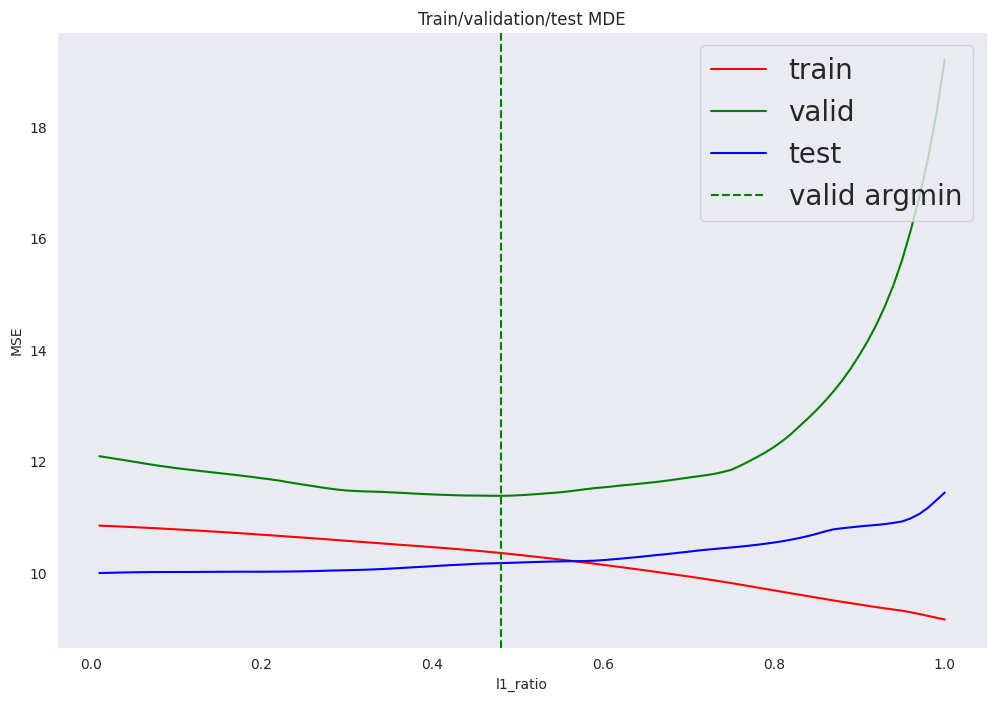

In [168]:
plt.plot(l1_ratio_list, mse_train, c='r', label='train')
plt.plot(l1_ratio_list, np.array(mse_valid)/7, c='g', label='valid')
plt.plot(l1_ratio_list, mse_test, c='b', label='test')

x = sorted(zip(l1_ratio_list, mse_valid), key=lambda t: t[1])[0][0]
plt.axvline(x, color='g', linestyle='--', label='valid argmin')

plt.legend(loc='upper right', prop={'size': 20})
plt.title('Train/validation/test MDE')
plt.xlabel('l1_ratio')
plt.ylabel('MSE')
plt.show()

To search in bigger space of hyperparameters sklearn have Pipeline class (http://scikit-learn.org/stable/modules/pipeline.html), which can be used to chain multiple estimators into one. This is useful as there is often a fixed sequence of steps in processing the data, for example feature selection, normalization and classification (Polynomial $\large \rightarrow$ StandardScalar $\large \rightarrow$ ElasticNet). Pipeline serves two purposes here:
* Convenience: You only have to call fit and predict once on your data to fit a whole sequence of estimators.
* Joint parameter selection: You can grid search over parameters of all estimators in the pipeline at once.

And we have GridSearchCV class (http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) which can do for us exhaustive search over specified parameter values for an estimator (we will use Pipeline as estimator). It is equivalent to search in the set of hypothesis space.

In [169]:
# import Pipeline from sklearn
from sklearn.pipeline import Pipeline

In [170]:
# create pipe with three steps
pipe = Pipeline(steps=[
    ('pf', PolynomialFeatures(include_bias=False)),
    ('ss', StandardScaler()),
    ('en', ElasticNet())
])
pipe.named_steps

{'pf': PolynomialFeatures(include_bias=False),
 'ss': StandardScaler(),
 'en': ElasticNet()}

In [171]:
# import GridSearchCV from sklearn
from sklearn.model_selection import GridSearchCV

In [173]:
parameters = {
    'pf__degree': [1, 2, 3],
    'en__alpha': [0.001, 0.01, 0.02, 0.1, 0.5],
    'en__l1_ratio': [0.001, 0.01, 0.1, 0.5, 0.9, 1]
}

for k, v in parameters.items():
    print(k, v)

pf__degree [1, 2, 3]
en__alpha [0.001, 0.01, 0.02, 0.1, 0.5]
en__l1_ratio [0.001, 0.01, 0.1, 0.5, 0.9, 1]


In [174]:
# import helper function which converts metrics into score function for GridSearch
from sklearn.metrics import make_scorer

grid_search = GridSearchCV(pipe, parameters, cv=3, n_jobs=1, verbose=1)

grid_search = grid_search.fit(data['x_train'], data['y_train'])

Fitting 3 folds for each of 90 candidates, totalling 270 fits


/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.105e+03, tolerance: 2.393e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.070e+03, tolerance: 2.661e+00
  model = cd_fast.enet_coordinate_descent(
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the featu

In [175]:
print('Best params:', grid_search.best_params_)
print('Test score:', mean_squared_error(data['y_test'], grid_search.predict(data['x_test'])))

Best params: {'en__alpha': 0.1, 'en__l1_ratio': 0.1, 'pf__degree': 2}
Test score: 9.711930208865146


![5fcv](images/sklearn.png)

# Bayesian interpretation of LR
![5fcv](images/bayes_app.png)

## Recap of propability
* Joint probability: $\large p\left(x, y\right)$ is propability that both rv falls in same range or in discrete set ov values

* Marginal probability: $\large p\left(x\right) = \sum_y p\left(x, y\right)$

* Condition probability: $\large p\left(x \mid y\right)$ is probability of rv $\large x$ given that $\large y$ is already resolved; $\large p\left(x, y\right) = p\left(x \mid y\right) p\left(y\right) = p\left(y \mid x\right) p\left(x\right)$

* Bayes theorem: $\large p\left(y \mid x\right) = \dfrac{p\left(x \mid y\right) p\left(y\right)}{p\left(x\right)} = \dfrac{p\left(x \mid y\right) p\left(y\right)}{\sum_{z} p\left(x \mid z\right) p\left(z\right)}$

* Independence: $\large p\left(x, y\right) = p\left(x\right) p\left(y\right)$

## Simple example
* Let test for some disease gives true result in 95% of cases
* 1% of all people have that disease
* Somebody made this test today and it said that he has that disease
* What is the probability that that person have that disease?

In [ ]:
p_test = 0.95
p_prior = 0.01
p_disease = p_test*p_prior / (p_test*p_prior + (1 - p_test)*(1 - p_prior))
print('Answer is %2.2f%%' % (p_disease*100))

Answer is 16.10%


$$\Large \color{green}{p\left(y \mid x\right)} = \dfrac{\color{orange}{p\left(x \mid y\right)} \color{blue}{p\left(y\right)}}{\color{red}{p\left(x\right)}}$$
where:
* $\large \color{blue}{p\left(y\right)}$ 
    * Prior: how probable was our hypothesis *before* observing the evidence?
* $\large \color{orange}{p\left(x \mid y\right)}$ 
    * Likelihood: how probable is the evidence given that our hypothesis is true?
* $\large \color{red}{p\left(x\right) = \sum_{z} p\left(x \mid z\right) p\left(z\right)}$ 
    * Marginal: how probable is the new evidence under all possible hypothesis?
* $\large \color{green}{p\left(y \mid x\right)}$ 
    * Posterior: how probable is our hypothesis given the observed evidence?
    
In statistics we usually seek for *maximum likelihood* hypothesis:
$$\large \theta_{\text{ML}} = \arg \max_{\theta} p\left(D \mid \theta\right)$$

In bayesian approach we seek for *posterior distribution*:

$$\large p\left(\theta \mid D \right) \propto p\left(D \mid \theta\right) p\left( \theta \right)$$

and for *maximum a posteriori* hypothesis:

$$\large \theta_{\text{MAP}} = \arg \max_{\theta} p\left(\theta \mid D\right) = \arg \max_{\theta} p\left( D \mid \theta\right) p\left(\theta\right)$$

Lets look at example using Gaussian (Normal) distribution, which arise in a lot of real world applications, where exist some mean value $\large \mu$ and noise:

$$\large p\left(x \mid \mu, \sigma\right) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\dfrac{\left(x - \mu\right)^2}{2\sigma^2}}$$

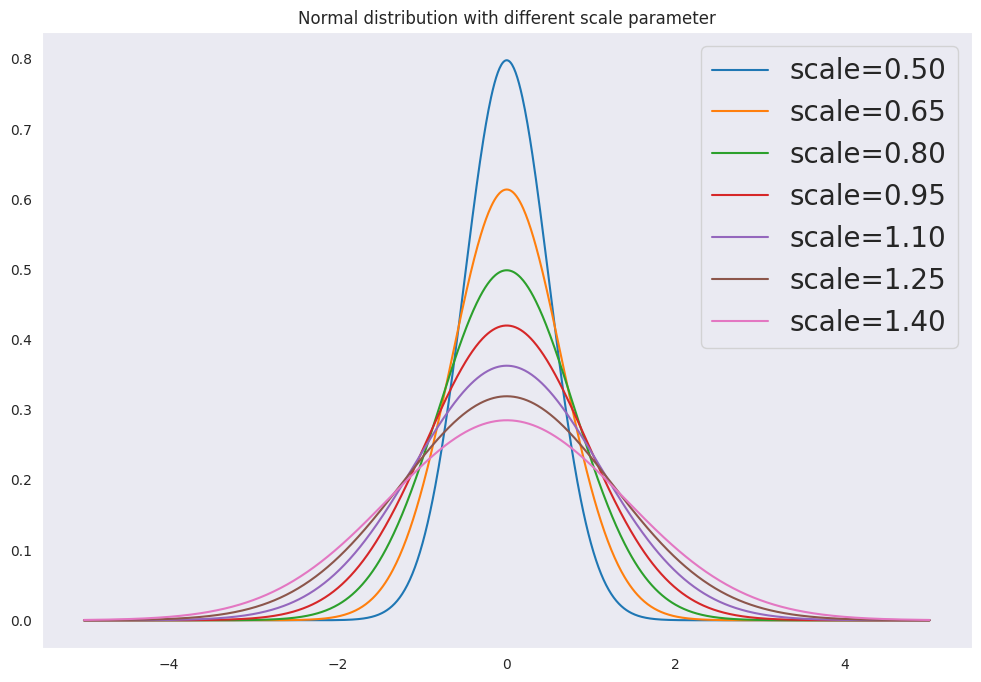

In [ ]:
x = np.linspace(-5, 5, 1000)
for scale in np.linspace(0.5, 1.4, 7):
    plt.plot(x, norm.pdf(x, scale=scale), label='scale=%0.2f' % scale)
    
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Normal distribution with different scale parameter')
plt.show()

If samples in dataset $\large D = \left\{x_i\right\}_{i=1,\ldots,n}$ are iid (independent and identically-distributed), then we can write likelihood of dataset:

$$\large \begin{array}{rcl} L = p\left(x_1, \ldots, x_n \mid \mu, \sigma\right) &=& \prod_{i=1}^n p\left(x_i \mid \mu, \sigma \right) \\
&=& \prod_{i=1}^n \frac{1}{\left(\sigma\sqrt{2\pi}\right)^n} e^{-\frac{\left(x_i - \mu\right)^2}{2\sigma^2}} \\
&=& \frac{1}{\left(\sigma\sqrt{2\pi}\right)^n} e^{-\frac{1}{2\sigma^2}\sum_{i=1}^n \left(x_i - \mu\right)^2}
\end{array}$$

## Return to LR
Lets assume that our true target variable is composed of some deterministic function, for example linear, and some normally  distributed noise with zero mean and some variance:

$$\large y = \vec{w}^T \vec{x} + \epsilon, \epsilon \sim \mathcal{N}\left(0, \sigma^2\right)$$

which is same as:

$$\large p\left(y \mid \vec{x}, \vec{w}, \sigma^2\right) = \mathcal{N}\left(y \mid \vec{w}^T \vec{x}, \sigma^2\right)$$

then likelihood is (data is iid):
$$\large p\left(\vec{y} \mid X, \vec{w}, \sigma^2\right) = \prod_{i=1}^n \mathcal{N}\left(y_i \mid \vec{w}^T \vec{x}_i, \sigma^2\right)$$

lets apply logarithmic transformation:
$$\large \begin{array}{rcl}\mathcal{L} &=& \ln p\left(\vec{y} \mid X, \vec{w}, \sigma^2\right) \\
&=& \ln \prod_{i=1}^n \mathcal{N}\left(y_i \mid \vec{w}^T \vec{x}_i, \sigma^2\right) \\
&=& \ln \frac{1}{\left(\sigma \sqrt{2\pi}\right)^n} e^{-\frac{1}{2\sigma^2} \sum_{i=1}^n \left(y_i - \vec{w}^T \vec{x}_i\right)^2} \\
&=& -\frac{n}{2}\ln 2\pi\sigma^2 -\frac{1}{2\sigma^2} \sum_{i=1}^n \left(y_i - \vec{w}^T \vec{x}_i\right)^2
\end{array}$$

If we assume that $\large \sigma = 1$, then maximum likelihood hypothesis is exactly same as OLS solution. The only difference is that we try to maximize $\large \mathcal{L}$, but right side part of equation is with minus sign.

To illustrate ML solution lets generate new "sine" dataset and plot density of likelihood.

In [95]:
# provides tools for iterating
import itertools as it
# import color maps from matlpotlib
from matplotlib import cm

In [96]:
# prepare data
data = generate_wave_set(1000, 100)
X = np.vstack((np.ones(data['x_train'].shape[0]), data['x_train'])).T

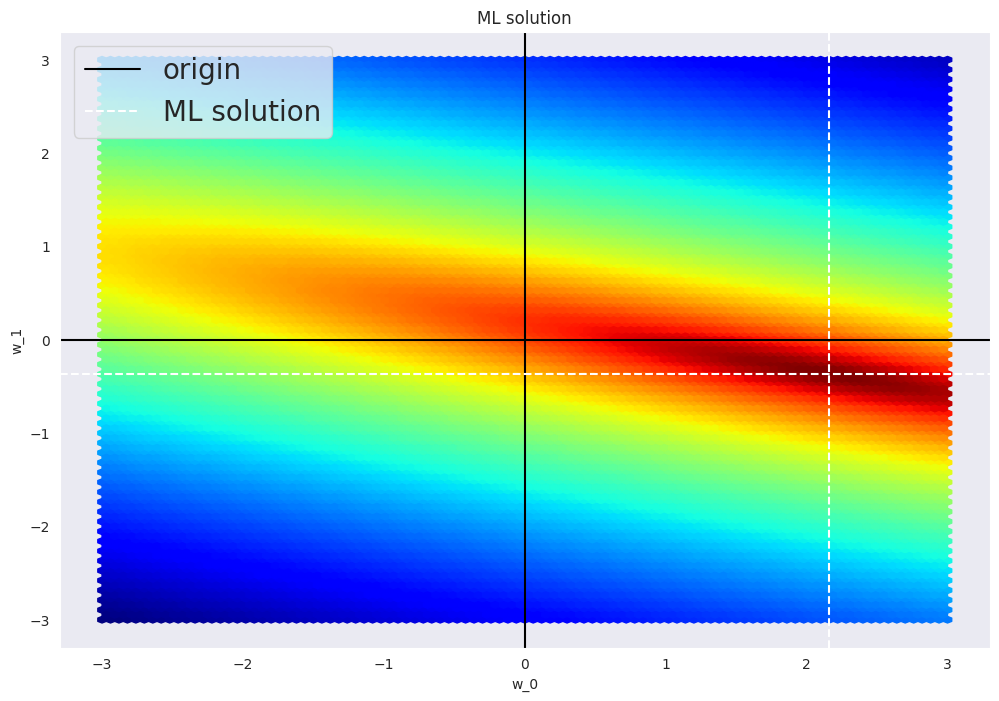

In [104]:
# find ML estimation
w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), data['y_train'])

# plot
# prepare value space for different values of parameters of the model
w0_support = np.linspace(-3, 3, 1000)
w1_support = np.linspace(-3, 3, 1000)
# create cartesian product of parameters
wx_space = list(it.product(w0_support, w1_support))
w0, w1 = zip(*wx_space)
# calculate MSE on dataset for each pairs of parameters
y = ((data['y_train'][:, np.newaxis] - np.dot(X, np.array(wx_space).T))**2).mean(axis=0)

plt.hexbin(w0, w1, C=y**(0.2), cmap=cm.jet_r, bins=None)
plt.axvline(0, color='black', linestyle='-', label='origin')
plt.axhline(0, color='black', linestyle='-')
plt.axvline(w[0], color='w', linestyle='--', label='ML solution')
plt.axhline(w[1], color='w', linestyle='--')
# plt.axes().set_aspect('equal', 'datalim')
plt.title('ML solution')
plt.xlabel('w_0')
plt.ylabel('w_1')
plt.legend(loc='upper left', prop={'size': 20})
# plt.show()

Actually there were implicit declared that we use uniford prior for parameters of the model, so that all values where equally probable. Lets add some other prior, such that some values of $\large \vec{w}$ will be more probable then others. Lets try to use normal distribution: $\large p\left(\vec{w}\right) = \mathcal{N}\left(\vec{w} \mid 0, \sigma_0^2 E\right)$

Then posterior distribution will be proportional to:
$$\large p\left(\vec{y} \mid X, \vec{w}, \sigma^2\right) \propto \mathcal{N}\left(\vec{w} \mid 0, \sigma_0^2 E\right) \prod_{i=1}^n \mathcal{N}\left(y_i \mid \vec{w}^T \vec{x}_i, \sigma^2\right)$$

Again, after logarithmic transformation we will get same equation as for L2 regularization, also we got know that $\large \lambda = \frac{1}{2\sigma_0^2}$. Lets plot solutions of MAP.

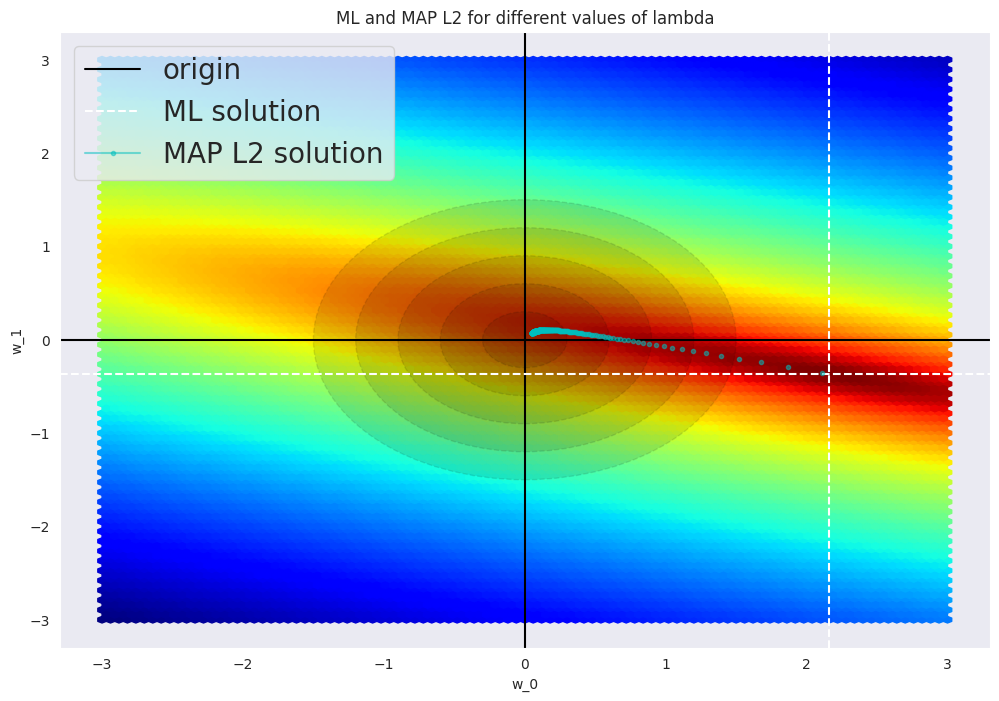

In [105]:
w = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), data['y_train'])

# solve L2 problems for different values of 
w_l2 = {}
lmbd_space = np.linspace(0.5, 1500, 500)
for lmbd in lmbd_space:
    w_l2[lmbd] = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X) + lmbd*np.eye(X.shape[1])), X.T), data['y_train'])
    
w0_support = np.linspace(-3, 3, 1000)
w1_support = np.linspace(-3, 3, 1000)
wx_space = list(it.product(w0_support, w1_support))
w0, w1 = zip(*wx_space)
y = ((data['y_train'][:, np.newaxis] - np.dot(X, np.array(wx_space).T))**2).mean(axis=0)


plt.hexbin(w0, w1, C=y**(0.2), cmap=cm.jet_r, bins=None)
plt.axvline(0, color='black', linestyle='-', label='origin')
plt.axhline(0, color='black', linestyle='-')
# plot prior distribution of parameters
for i in range(1, 6):
    plt.gcf().gca().add_artist(plt.Circle((0, 0), i*0.3, color='black', linestyle='--', alpha=0.1))
plt.axvline(w[0], color='w', linestyle='--', label='ML solution')
plt.axhline(w[1], color='w', linestyle='--')
# plot MAP solutions
flag = True
for _, w_l2_solution in w_l2.items():
    plt.plot(w_l2_solution[0], w_l2_solution[1], color='c', marker='.', mew=1, alpha=0.5, 
             label='MAP L2 solution' if flag else None)
    flag = False
# plt.axes().set_aspect('equal', 'datalim')
plt.title('ML and MAP L2 for different values of lambda')
plt.xlabel('w_0')
plt.ylabel('w_1')
plt.legend(loc='upper left', prop={'size': 20})
plt.show()

Lets try to change normal distribution to another one. For example Laplace distridution:

$$\large p\left(x \mid \mu, \beta\right) = \frac{1}{2\beta} e^{-\dfrac{\left|x - \mu\right|}{\beta}}$$

In [106]:
from scipy.stats import laplace

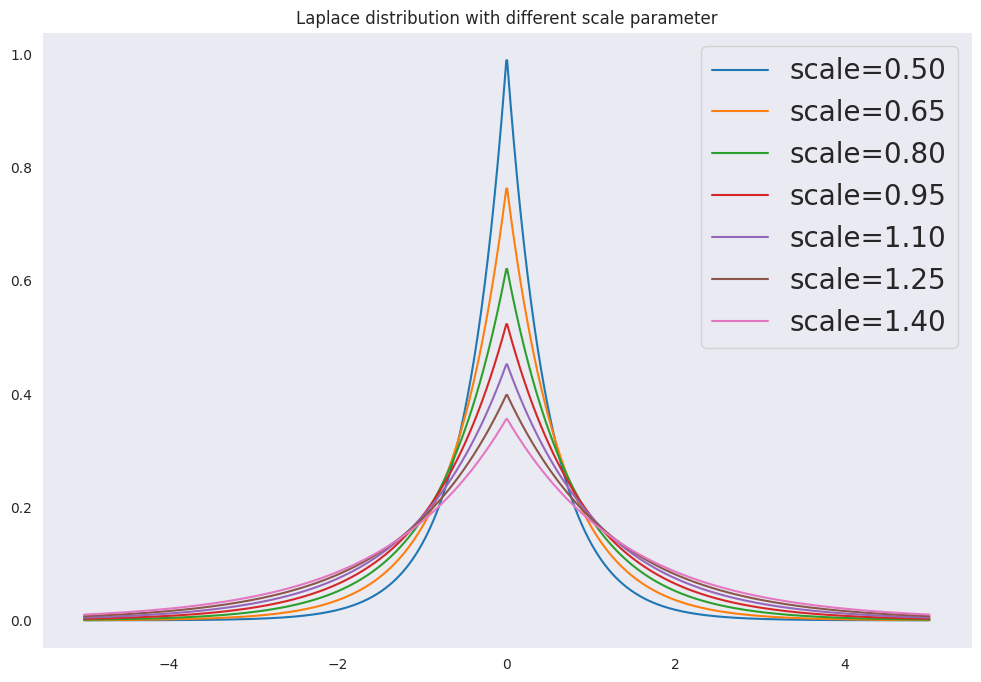

In [107]:
x = np.linspace(-5, 5, 1000)
for scale in np.linspace(0.5, 1.4, 7):
    plt.plot(x, laplace.pdf(x, scale=scale), label='scale=%0.2f' % scale)
    
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Laplace distribution with different scale parameter')
plt.show()

So new prior for parameter is: $\large p\left(\vec{w}\right) = \text{Laplace}\left(\vec{w} \mid 0, \beta E\right)$

Then posterior distribution will be proportional to:
$$\large p\left(\vec{y} \mid X, \vec{w}, \sigma^2\right) \propto \text{Laplace}\left(\vec{w} \mid 0, \beta\right) \prod_{i=1}^n \mathcal{N}\left(y_i \mid \vec{w}^T \vec{x}_i, \sigma^2\right)$$

Again, after logarithmic transformation we will get same equation as for L1 regularization, also we got know that $\large \lambda = \frac{1}{\beta}$. Lets plot solutions of MAP.

In [109]:
from tqdm import tqdm

w_l1 = {}
lmbd_space = np.linspace(0.001, 2, 200)
for lmbd in tqdm(lmbd_space):
    w_l1[lmbd] = fit_lr_l1(X, data['y_train'], lmbd, n_iter=10000, lr=0.001)[0]

100%|██████████| 200/200 [00:18<00:00, 10.62it/s]


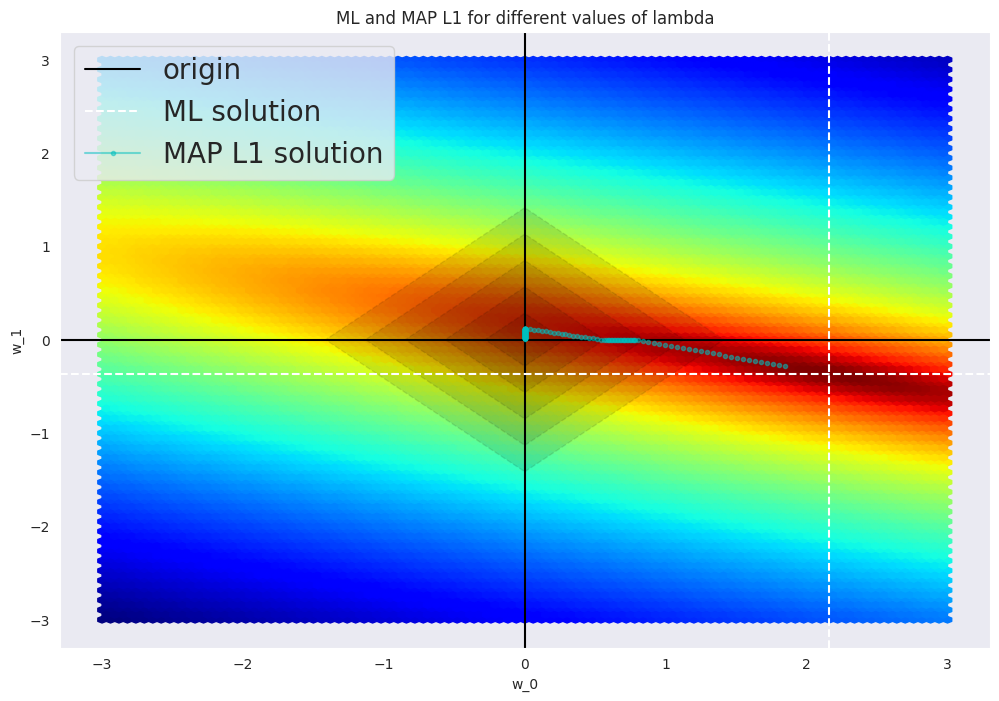

In [110]:
w0_support = np.linspace(-3, 3, 1000)
w1_support = np.linspace(-3, 3, 1000)
wx_space = list(it.product(w0_support, w1_support))
w0, w1 = zip(*wx_space)
y = ((data['y_train'][:, np.newaxis] - np.dot(X, np.array(wx_space).T))**2).mean(axis=0)


plt.hexbin(w0, w1, C=y**(0.2), cmap=cm.jet_r, bins=None)
plt.axvline(0, color='black', linestyle='-', label='origin')
plt.axhline(0, color='black', linestyle='-')

# function to plot rhomb
def plot_rhomb(cx=0, cy=0, r=0.5):
    plt.gcf().gca().add_artist(plt.Rectangle((cx, cy - np.sqrt(2*r**2)), 2*r, 2*r, angle=45, 
                                             color='black', linestyle='--', alpha=0.1))
# plot Laplace distribution density
for i in range(1, 6):
    plot_rhomb(r=0.2*i)
plt.axvline(w[0], color='w', linestyle='--', label='ML solution')
plt.axhline(w[1], color='w', linestyle='--')
# plot MAP solutions
flag = True
for _, w_l1_solution in w_l1.items():
    plt.plot(w_l1_solution[0], w_l1_solution[1], color='c', marker='.', mew=1, alpha=0.5, 
             label='MAP L1 solution' if flag else None)
    flag = False

# plt.axes().set_aspect('equal', 'datalim')
plt.title('ML and MAP L1 for different values of lambda')
plt.xlabel('w_0')
plt.ylabel('w_1')
plt.legend(loc='upper left', prop={'size': 20})
plt.show()

We can see that again L1 regularization gives us sparce solutions. To illustrate sparsity solutions in more details we will use special type of plotting.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

raw_df = pd.read_csv('/opt/d.sidorko/ocr_research/study/mlcourse.ai/data/Boston.csv', sep=",", index_col=0)

print('Shape of the data:', raw_df.shape)
data = {}
data['x_train'] = raw_df.drop(['medv'], axis=1)
data['y_train'] = raw_df['medv']
data['x_train'] = StandardScaler().fit_transform(data['x_train'])

Shape of the data: (506, 14)


In [131]:
# solve LR L1 for fifty lambdas from 0 to 1.5
lmbd_space = np.linspace(0, 1.5, 50)

ws = []
for lmbd in tqdm(lmbd_space):
    ws.append(fit_lr_l1(np.hstack((np.ones(data['x_train'].shape[0])[:, np.newaxis], data['x_train'])), 
                         data['y_train'], lmbd=lmbd, n_iter=10000, lr=0.001)[0])
ws = np.array(ws)

100%|██████████| 50/50 [01:33<00:00,  1.87s/it]


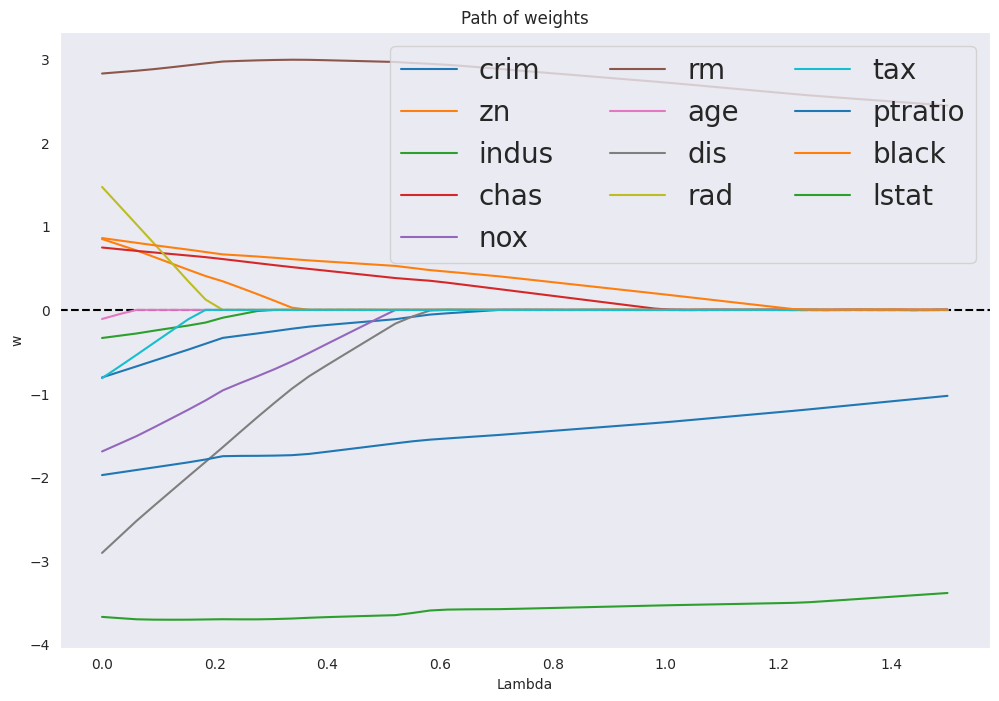

In [133]:
plt.axhline(0, color='black', linestyle='--')

for i in range(1, ws.shape[1]):
    plt.plot(lmbd_space, ws[:, i], label=raw_df.columns[i - 1])
    
plt.title('Path of weights')
plt.xlabel('Lambda')
plt.ylabel('w')
plt.legend(loc='upper right', prop={'size': 20}, ncol=3)
plt.show()

1. CRIM: per capita crime rate by town 
* ZN: proportion of residential land zoned for lots over 25,000 sq.ft. 
* INDUS: proportion of non-retail business acres per town 
* CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) 
* NOX: nitric oxides concentration (parts per 10 million) 
* RM: average number of rooms per dwelling 
* AGE: proportion of owner-occupied units built prior to 1940 
* DIS: weighted distances to five Boston employment centres 
* RAD: index of accessibility to radial highways 
* TAX: full-value property-tax rate per 10000\$
* PTRATIO: pupil-teacher ratio by town 
* B: 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town 
* LSTAT: % lower status of the population 
* MEDV: Median value of owner-occupied homes in $1000's

Actually we can use different $\large \mathscr{l}^\mathcal{p}$ norm for regularization:

$$\large \left\|x\right\|_p = \left( \sum_{i=1}^\infty \left|x\right|^p \right)^{\frac{1}{p}}$$

In [139]:
a = [[[1, 2], [2, 3]], [[3, 4], [4, 5]]]
ax = reduce(lambda a, b: a + b, a)
ax

[[1, 2], [2, 3], [3, 4], [4, 5]]

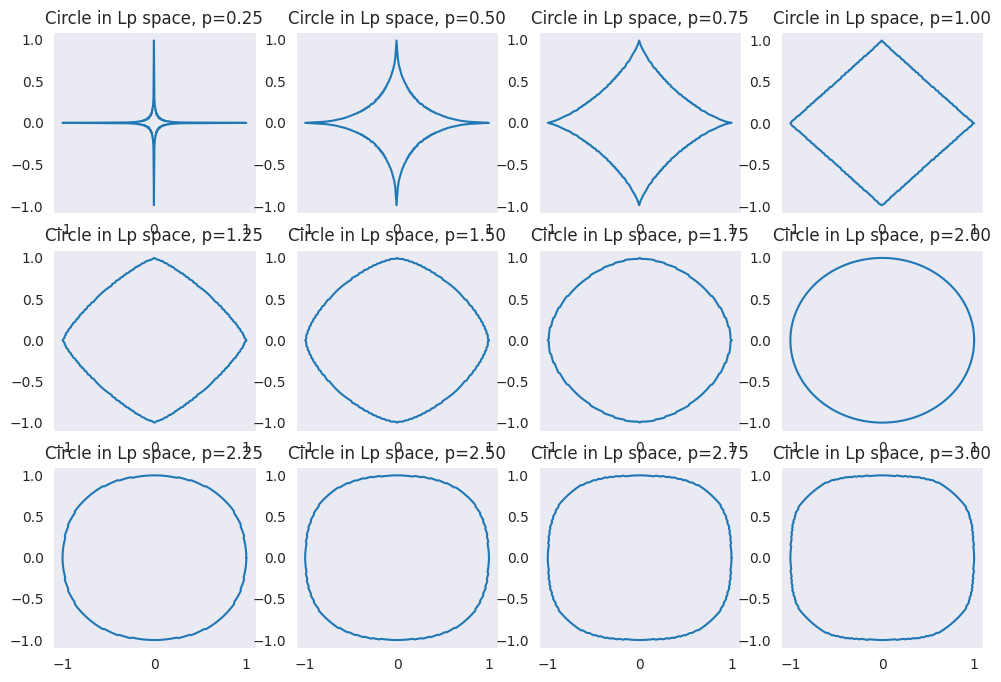

In [140]:
from functools import reduce

f, ax = plt.subplots(3, 4)
ax = reduce(lambda a, b: a + b, ax.tolist())

a_list = np.linspace(0, 2*np.pi, 361)
r_list = np.linspace(0, 1.1, 100)

for ix, p in enumerate(np.linspace(0.25, 3, 12)):
    points = []
    for a in a_list:
        r_inner = []
        for r in r_list:
            if np.linalg.norm([r*np.cos(a), r*np.sin(a)], p) > 1:
                break
            r_inner.append(r)
        r = max(r_inner)
        points.append([r*np.cos(a), r*np.sin(a)])
    points = np.array(points)
    
    ax[ix].plot(points[:, 0], points[:, 1])
    # ax[ix].set_aspect('equal', 'datalim')
    ax[ix].set_title('Circle in Lp space, p=%0.2f' % p)

Or in other words, we can use generalized normal distribution as a prior for parameters:

$$\large p\left(x \mid \alpha, \beta, \mu\right) = \frac{\beta}{2\alpha \Gamma\left(\frac{1}{\beta}\right)} e^{-\left(\frac{\left|x - \mu\right|}{\alpha}\right)^\beta}$$

In [142]:
from scipy.stats import gennorm

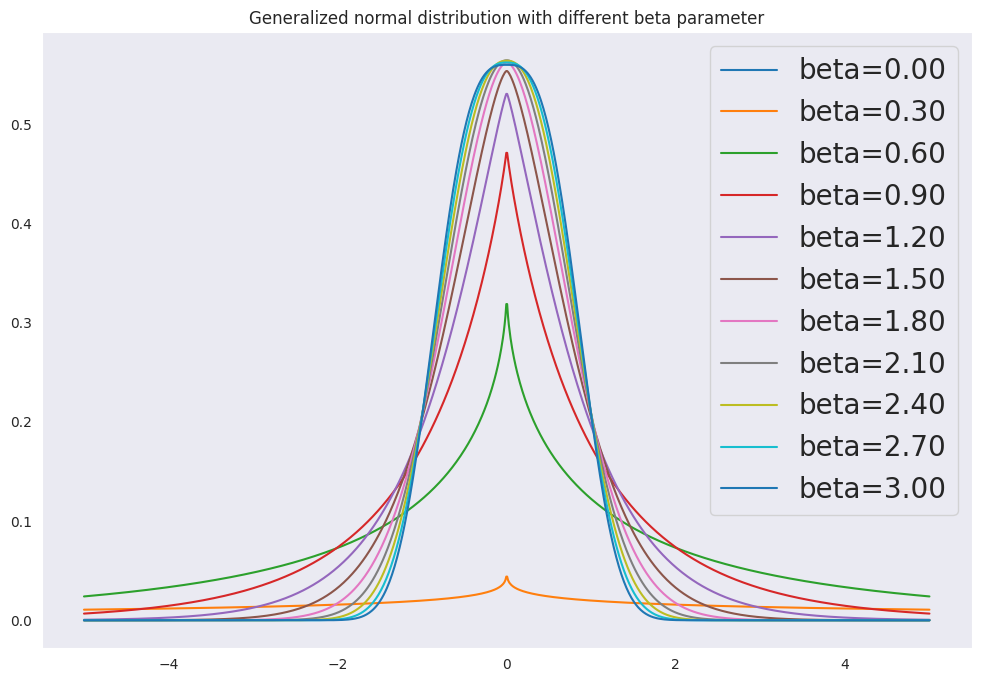

In [143]:
x = np.linspace(-5, 5, 1000)
for beta in np.linspace(0, 3, 11):
    plt.plot(x, gennorm.pdf(x, beta=beta), label='beta=%0.2f' % beta)
    
plt.legend(loc='upper right', prop={'size': 20})
plt.title('Generalized normal distribution with different beta parameter')
plt.show()

# Logistic regression

Let we have two classes, then usin Bayes theorem we can write probability of one class given features (for simplicity lets assume that we have only one feature):
$$\large \begin{array}{rcl} p\left(c = 0 \mid x \right) &=& \frac{p\left(x \mid c = 0\right) p\left(c = 0\right)}{p\left(x \mid c = 0\right) p\left(c = 0\right) + p\left(x \mid c = 1\right) p\left(c = 1\right)} \\
&=& \frac{1}{1 + e^{-a}} = \sigma\left(a\right)
\end{array}$$

where:
$$\large a = \ln \frac{p\left(x \mid c = 0\right) p\left(c = 0\right)}{p\left(x \mid c = 1\right) p\left(c = 1\right)}$$
$\large a$ is called log odds.

Lets also assume that in each class features have normal distribution with different mean, but same variance:
$$\large p\left( x \mid c = k \right) \sim \mathcal{N}\left( \mu_k, \sigma \right)$$

also, lets for now assume that classes are equally probable, then:
$$\large \begin{array}{rcl} a &=& \ln \frac{p\left(x \mid c = 0\right)}{p\left(x \mid c = 1\right)} \\
&=& \ln p\left(x \mid c = 0\right) - \ln p\left(x \mid c = 1\right)\\
&=& \frac{1}{2\sigma^2} \left(\mu_1 - x\right)^2 -\frac{1}{2\sigma^2} \left(\mu_0 - x\right)^2 \\
&=& \frac{1}{2\sigma^2} \left(\left(\mu_1 - x\right)^2 - \left(\mu_0 - x\right)^2\right) \\
&=& \frac{1}{2\sigma^2} \left(\mu_1^2 - 2\mu_1 x + x^2 - \mu_0^2 + 2 \mu_0 x - x^2\right) \\
&=& \frac{\mu_1^2 - \mu_0^2}{2\sigma^2} + \frac{\mu_0 - 2\mu_1}{\sigma^2}x \\
&=& w_0 + w_1 x\\
\end{array}$$


So we can see that sigmoid function arise naturally if we assume that features are normally distributed given a class.

*Logistic regression* - is the model where $\large \vec{w}$ is optimized directly. 

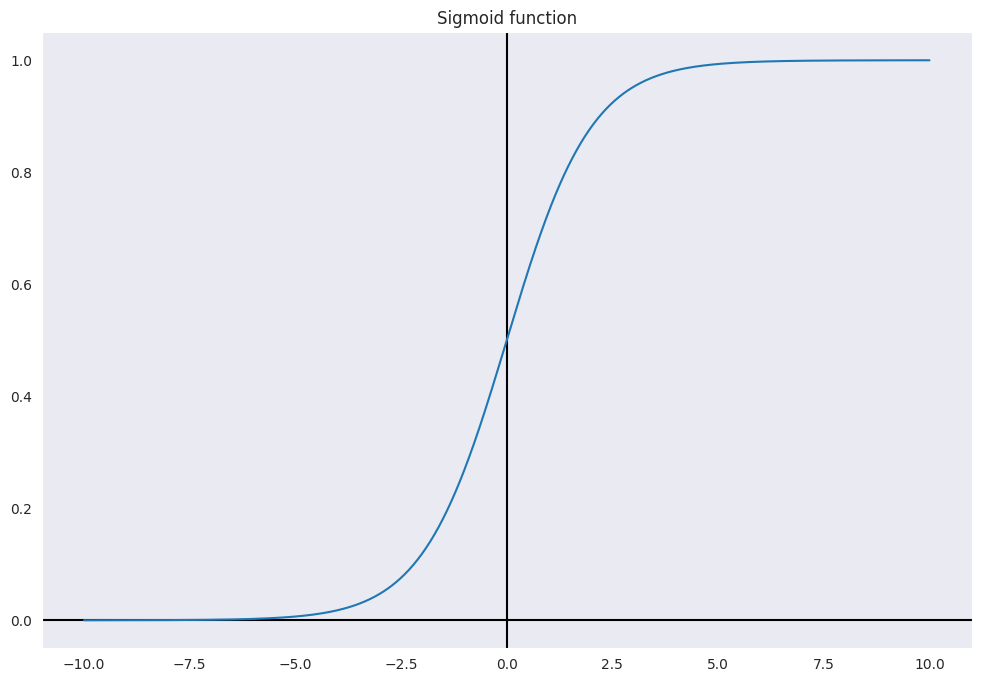

In [144]:
# define scalar function
def sigmoid(x):
    return 1/(1 + np.exp(-x))

# make vectorized function from scalar
sigmoid = np.vectorize(sigmoid)

x = np.linspace(-10, 10, 1000)

plt.axvline(0, color='black', linestyle='-', label='origin')
plt.axhline(0, color='black', linestyle='-')
plt.plot(x, sigmoid(x))
plt.title('Sigmoid function')
plt.show()

One more good property of sigmoid function it is that its derivative wrt to argument can be expressed throught sigmoid:

$$\large \frac{\partial \sigma\left(x\right)}{\partial x} = \sigma\left(x\right) \left(1 - \sigma\left(x\right)\right)$$

Lets recap Bernoulli distribution - it is distribution of rv which takes value 1 with probability $\large p$, and value 0 with probability $\large q = 1 - p$:
$$\large p\left(k \mid p\right) = p^k \left(1 - p\right)^{1 - k}$$

Short example: let we have a coin and we toss in $\large n + m$ times, where $\large n$ outcomes we head and $\large m$ were tails. Lets find ML estimation of $\large p(\text{head}) = p$

$$\large \begin{array}{rcl}\mathcal{L} &=& \ln p^n \left(1 - p\right)^m \\
\frac{\partial \mathcal{L}}{\partial p} &=& \frac{n}{p} - \frac{m}{1 - p} \\
\frac{\partial \mathcal{L}}{\partial p} = 0 &\Leftrightarrow& \frac{n}{p} = \frac{m}{1 - p} \\
&\Leftrightarrow& p = \frac{n}{n + m}
\end{array}$$

Lets do same with classification problem setup, where we have dataset $\large D = \left\{\left(\vec{x}_i, y_i\right)\right\}_{i=1,\ldots,n}$, $\large \forall i, y_i \in \left\{0, 1\right\}$, then likelihood of the dataset is:

$$\large \begin{array}{rcl}\mathcal{L} &=& \ln \prod_{i=1}^n p\left(c = 0 \mid \vec{x}_i \right)^{y_i} \left(1 - p\left(c = 0 \mid \vec{x}_i \right)\right)^{1 - y_i} \\
&=& \ln \prod_{i=1}^n \sigma\left(\vec{w}^T \vec{x}_i\right)^{y_i} \left(1 - \sigma\left(\vec{w}^T \vec{x}_i\right)\right)^{1 - y_i} \\
&=& \sum_{i=1}^n y_i \ln \sigma\left(\vec{w}^T \vec{x}_i\right) + \left(1 - y_i\right) \ln \left(1 - \sigma\left(\vec{w}^T \vec{x}_i\right)\right)
\end{array}$$

Lets find update rules for gradient descent:
$$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} &=& \frac{\partial}{\partial \vec{w}}\sum_{i=1}^n y_i \ln \sigma\left(\vec{w}^T \vec{x}_i\right) + \left(1 - y_i\right) \ln \left(1 - \sigma\left(\vec{w}^T \vec{x}_i\right)\right) \\
&=& \sum_{i=1}^n y_i \frac{1}{\sigma} \sigma \left(1 - \sigma\right) \vec{x}_i + \left(1 - y_i\right) \frac{1}{1 - \sigma} \left(-1\right)\sigma \left(1 - \sigma\right) \vec{x}_i \\
&=& \sum_{i=1}^n y_i \left(1 - \sigma\right) \vec{x}_i - \left(1 - y_i\right) \sigma \vec{x}_i \\
&=& \sum_{i=1}^n \vec{x}_i \left(y_i - \sigma\right)
\end{array}$$

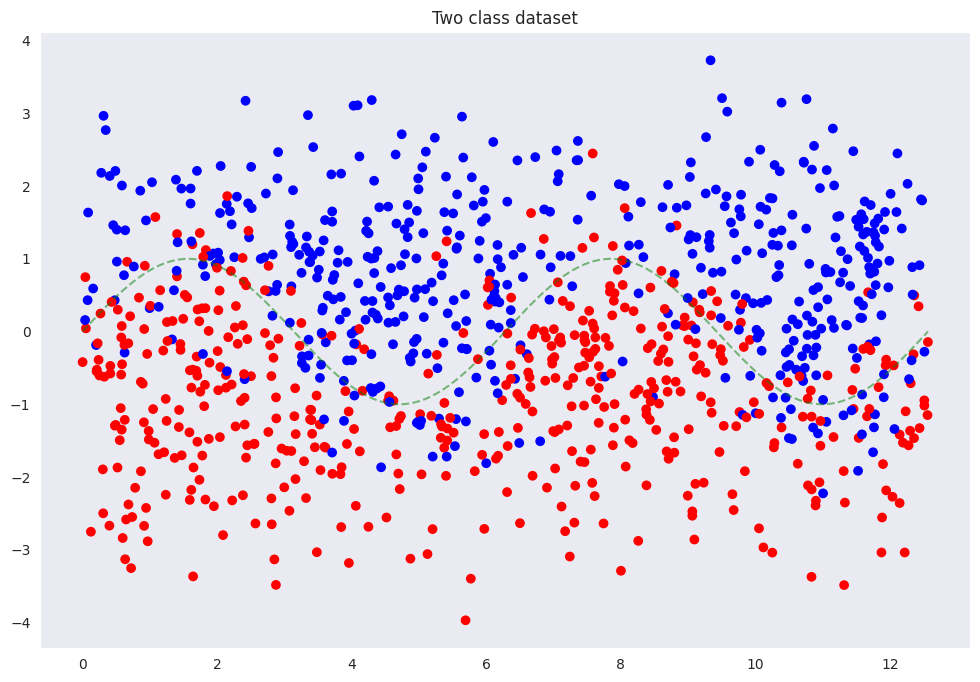

In [176]:
# lets create dataset for your homework

data = {}
data['support'] = np.linspace(0, 4*np.pi, num=1000)
data['values'] = np.sin(data['support'])

x = np.random.uniform(0, 4*np.pi, size=1000)
y = np.random.uniform(-2, 2, size=1000)
x_sin = np.sin(x)
c = (y >= x_sin).astype('int')
y = y + np.random.normal(0, 0.8, size=y.shape[0])

data['X'] = np.vstack((x, y)).T
data['y'] = c


plt.plot(data['support'], data['values'], 'g--', alpha=0.5, )
plt.scatter(x, y, c=list(map(lambda c: 'r' if c == 0 else 'b', c)))
plt.title('Two class dataset')
plt.show()

In [362]:
from sklearn.linear_model import LogisticRegression

# create pipe with three steps
pipe = Pipeline(steps=[
    ('pf', PolynomialFeatures()),
    ('ss', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10000))
])
pipe.named_steps

{'pf': PolynomialFeatures(),
 'ss': StandardScaler(),
 'lr': LogisticRegression(max_iter=10000)}

In [372]:
parameters = {
    'pf__degree': list(range(2, 10, 2)),
    'lr__C': np.logspace(-3, 3, 100)
}

for k, v in parameters.items():
    print(k, v)

pf__degree [2, 4, 6, 8]
lr__C [1.00000000e-03 1.14975700e-03 1.32194115e-03 1.51991108e-03
 1.74752840e-03 2.00923300e-03 2.31012970e-03 2.65608778e-03
 3.05385551e-03 3.51119173e-03 4.03701726e-03 4.64158883e-03
 5.33669923e-03 6.13590727e-03 7.05480231e-03 8.11130831e-03
 9.32603347e-03 1.07226722e-02 1.23284674e-02 1.41747416e-02
 1.62975083e-02 1.87381742e-02 2.15443469e-02 2.47707636e-02
 2.84803587e-02 3.27454916e-02 3.76493581e-02 4.32876128e-02
 4.97702356e-02 5.72236766e-02 6.57933225e-02 7.56463328e-02
 8.69749003e-02 1.00000000e-01 1.14975700e-01 1.32194115e-01
 1.51991108e-01 1.74752840e-01 2.00923300e-01 2.31012970e-01
 2.65608778e-01 3.05385551e-01 3.51119173e-01 4.03701726e-01
 4.64158883e-01 5.33669923e-01 6.13590727e-01 7.05480231e-01
 8.11130831e-01 9.32603347e-01 1.07226722e+00 1.23284674e+00
 1.41747416e+00 1.62975083e+00 1.87381742e+00 2.15443469e+00
 2.47707636e+00 2.84803587e+00 3.27454916e+00 3.76493581e+00
 4.32876128e+00 4.97702356e+00 5.72236766e+00 6.5793322

In [373]:
grid_search = GridSearchCV(pipe, parameters, cv=15, n_jobs=-1, verbose=1)
grid_search = grid_search.fit(data['X'], data['y'])
print('Best params:', grid_search.best_params_)
print('Best score:', grid_search.best_score_)

Fitting 15 folds for each of 400 candidates, totalling 6000 fits
Best params: {'lr__C': np.float64(432.87612810830615), 'pf__degree': 8}
Best score: 0.8360168852706165


7.8289310949509066


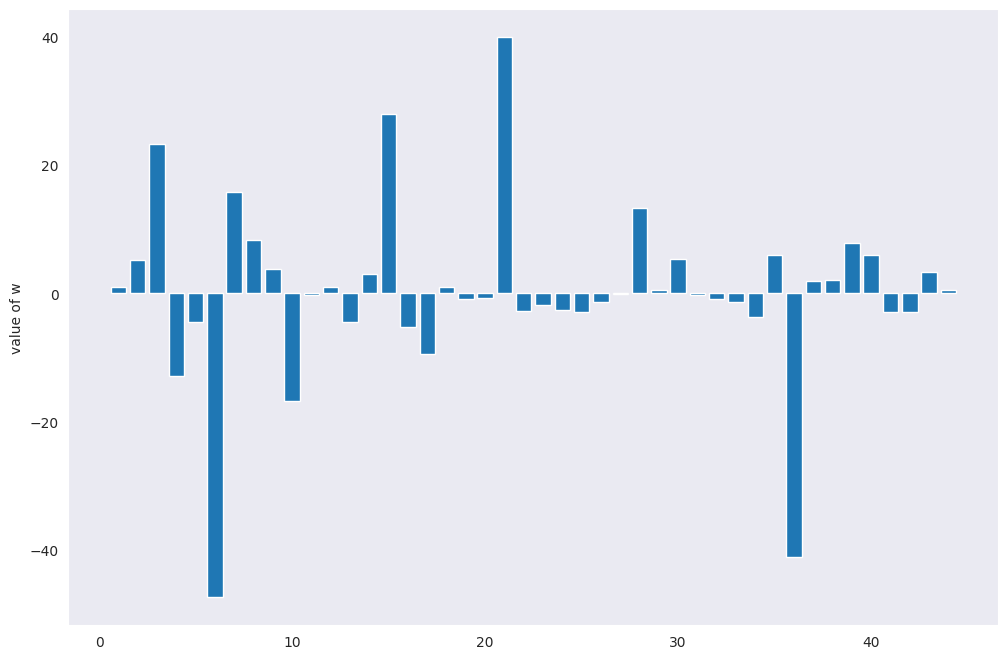

In [374]:
w = grid_search.best_estimator_.named_steps['lr'].coef_[0]
print(np.abs(w).mean())

plt.bar(range(1, len(w) + 1), w)
plt.ylabel('value of w')
plt.show()

In [293]:
def plot_boundary(clf, X, y, plot_title):
    xx, yy = np.meshgrid(np.linspace(-1, 13, 50), np.linspace(-4, 4, 50))
    clf.fit(X, y)
    Z = clf.predict_proba(np.vstack((xx.ravel(), yy.ravel())).T)[:, 1]
    Z = Z.reshape(xx.shape)
    print(X.shape)
    
    image = plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect="auto",
        origin="lower",
        cmap=plt.cm.PuOr_r,
    )
    
    plt.scatter(X[:, 0], X[:, 1], s=30, c=y, cmap=plt.cm.Paired)
    plt.xticks(())
    plt.yticks(())
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.colorbar(image)
    plt.title(plot_title, fontsize=12);
    
    plt.contour(xx, yy, Z, levels=[0.5], linewidths=2, linestyles="--")
    # Показать график
    plt.grid()
    plt.axhline(0, color='black', lw=0.5, ls='--')  # Добавить линию на уровне 0 по оси Y
    plt.axvline(0, color='black', lw=0.5, ls='--')  # Добавить линию на уровне 0 по оси X
    plt.show()

(1000, 2)


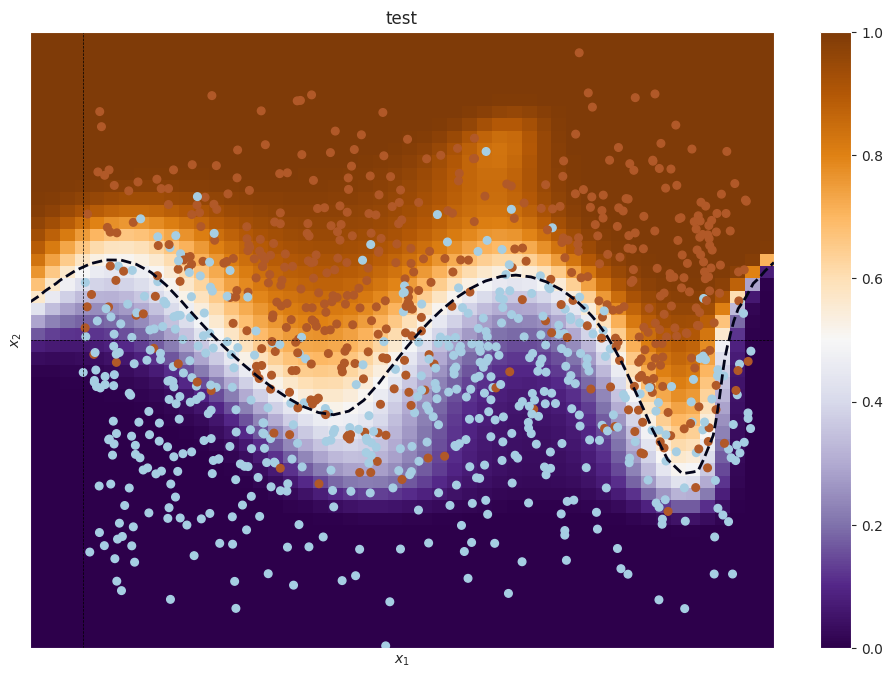

In [375]:
pipe = Pipeline(steps=[
    ('pf', PolynomialFeatures(degree=8, include_bias=False)),
    ('ss', StandardScaler()),
    ('lr', LogisticRegression(C=400, max_iter=10000))
])

plot_boundary(pipe, data['X'], data['y'], 'test')